In [2]:
# importing all the required libraries
import os
import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, mean_absolute_error, mean_squared_error
# import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import random

In [4]:
# 1. Load the combined dataset
combined = pd.read_csv('./dataset/Dataset.csv')

# 2. Split PART 1 - patients whose ID is NOT 6 digits long
rows_to_drop = combined.loc[combined['Patient_ID'].apply(lambda x: len(str(x)) == 6)]
df_train = combined.drop(rows_to_drop.index)   # keeps IDs != 6 digits
df_train.to_csv('data_part1.csv', index=False)

# 3. Split PART 2 - patients whose ID IS 6 digits long
rows_to_drop = combined.loc[combined['Patient_ID'].apply(lambda x: len(str(x)) != 6)]
df_test = combined.drop(rows_to_drop.index)    # keeps IDs == 6 digits
df_test.to_csv('data_part2.csv', index=False)

In [5]:
# Count unique patients who ever had SepsisLabel == 1
sepsis_patients = combined[combined['SepsisLabel'] == 1]['Patient_ID'].nunique()
total_patients  = combined['Patient_ID'].nunique()

print(f"Patients with Sepsis : {sepsis_patients}")
print(f"Total patients       : {total_patients}")
print(f"Percentage           : {sepsis_patients/total_patients*100:.2f}%")

Patients with Sepsis : 2932
Total patients       : 40336
Percentage           : 7.27%


In [6]:
for col in combined.columns:
    print(col)

Unnamed: 0
Hour
HR
O2Sat
Temp
SBP
MAP
DBP
Resp
EtCO2
BaseExcess
HCO3
FiO2
pH
PaCO2
SaO2
AST
BUN
Alkalinephos
Calcium
Chloride
Creatinine
Bilirubin_direct
Glucose
Lactate
Magnesium
Phosphate
Potassium
Bilirubin_total
TroponinI
Hct
Hgb
PTT
WBC
Fibrinogen
Platelets
Age
Gender
Unit1
Unit2
HospAdmTime
ICULOS
SepsisLabel
Patient_ID


In [8]:
def plot_all_vitals(df, hospital_name="Hospital", patient_id=None, seed=42):
    """
    Plots all available vitals for a single patient.
    
    Parameters
    ----------
    df          : raw combined dataframe with all columns
    hospital_name : label for the plot title
    patient_id  : specific patient ID to plot. If None, picks randomly.
    seed        : random seed for patient selection (ignored if patient_id given)
    """

    # -- Vital groups with display labels and colors -------------------
    vital_groups = {
        "Continuous Vitals": {
            "cols"   : ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "EtCO2"],
            "labels" : ["Heart Rate (bpm)", "O2 Saturation (%)", "Temperature (°C)",
                        "Systolic BP (mmHg)", "Mean Art. Pressure (mmHg)",
                        "Diastolic BP (mmHg)", "Resp Rate (br/min)", "EtCO2 (mmHg)"],
            "colors" : ["#2196F3", "#4CAF50", "#FF5722", "#F44336",
                        "#E91E63", "#FF9800", "#9C27B0", "#00BCD4"],
        },
        "Blood Gas": {
            "cols"   : ["pH", "PaCO2", "HCO3", "BaseExcess", "SaO2", "FiO2"],
            "labels" : ["pH", "PaCO2 (mmHg)", "HCO3 (mEq/L)",
                        "Base Excess", "SaO2 (%)", "FiO2 (%)"],
            "colors" : ["#1976D2", "#0097A7", "#388E3C",
                        "#7B1FA2", "#C2185B", "#F57C00"],
        },
        "Chemistry": {
            "cols"   : ["Lactate", "Glucose", "Creatinine", "Bilirubin_total",
                        "Calcium", "Potassium", "Magnesium"],
            "labels" : ["Lactate (mmol/L)", "Glucose (mg/dL)", "Creatinine (mg/dL)",
                        "Bilirubin Total (mg/dL)", "Calcium (mg/dL)",
                        "Potassium (mEq/L)", "Magnesium (mg/dL)"],
            "colors" : ["#D32F2F", "#FFA000", "#5D4037",
                        "#F9A825", "#558B2F", "#00838F", "#AD1457"],
        },
        "Hematology": {
            "cols"   : ["WBC", "Platelets", "Hgb", "Hct", "PTT", "Fibrinogen"],
            "labels" : ["WBC (K/uL)", "Platelets (K/uL)", "Hemoglobin (g/dL)",
                        "Hematocrit (%)", "PTT (sec)", "Fibrinogen (mg/dL)"],
            "colors" : ["#1565C0", "#6A1B9A", "#2E7D32",
                        "#4527A0", "#00695C", "#BF360C"],
        },
    }

    # -- Select patient ------------------------------------------------
    all_pids = df["Patient_ID"].unique().tolist()

    if patient_id is not None:
        if patient_id not in all_pids:
            raise ValueError(f"Patient {patient_id} not found in dataframe.")
        pid = patient_id
    else:
        rng = random.Random(seed)
        pid = rng.choice(all_pids)

    patient = df[df["Patient_ID"] == pid].sort_values("Hour").reset_index(drop=True)
    sepsis  = int(patient["SepsisLabel"].max())
    hours   = patient["Hour"].values

    print(f"{'='*55}")
    print(f"  Patient ID : {pid}")
    print(f"  Hospital   : {hospital_name}")
    print(f"  Hours      : {len(patient)}")
    print(f"  Sepsis     : {'Yes ' if sepsis else 'No'}")
    if sepsis:
        onset = patient[patient["SepsisLabel"] == 1]["Hour"].min()
        print(f"  Sepsis onset at hour : {onset}")
    print(f"{'='*55}\n")

    # -- Count non-null per group for subplot sizing -------------------
    available_groups = {}
    for group_name, info in vital_groups.items():
        available = [(c, l, col) for c, l, col in
                     zip(info["cols"], info["labels"], info["colors"])
                     if c in patient.columns]
        if available:
            available_groups[group_name] = available

    # -- Layout: one section per group, stacked vertically ------------
    total_rows = sum(len(v) for v in available_groups.values())
    fig, axes  = plt.subplots(total_rows, 1,
                               figsize=(16, 2.8 * total_rows),
                               sharex=True)
    if total_rows == 1:
        axes = [axes]

    ax_idx = 0
    for group_name, vitals in available_groups.items():
        for i, (col, label, color) in enumerate(vitals):
            ax = axes[ax_idx]

            values  = patient[col].values
            n_total = len(values)
            n_obs   = int(np.sum(~np.isnan(values)))
            pct_obs = n_obs / n_total * 100

            # Plot observed values
            ax.plot(hours, values, color=color, linewidth=1.5,
                    marker="o", markersize=3, label=label)

            # Mark missing values at y-axis bottom
            missing_mask = np.isnan(values)
            if missing_mask.any():
                ymin = np.nanmin(values) if n_obs > 0 else 0
                ax.scatter(hours[missing_mask],
                           [ymin] * missing_mask.sum(),
                           color="red", marker="x",
                           s=40, linewidths=1.2,
                           label=f"Missing ({100-pct_obs:.0f}%)",
                           zorder=5)

            # Sepsis shading
            if sepsis:
                sepsis_hours = patient[patient["SepsisLabel"] == 1]["Hour"]
                if not sepsis_hours.empty:
                    ax.axvspan(sepsis_hours.min(), sepsis_hours.max(),
                               alpha=0.12, color="red", label="Sepsis period")

            # Group label on first vital of each group
            if i == 0:
                ax.set_title(group_name, fontsize=10,
                             fontweight="bold", loc="left",
                             color="#333333", pad=4)

            ax.set_ylabel(label, fontsize=8, labelpad=4)
            ax.legend(loc="upper right", fontsize=7, framealpha=0.7)
            ax.grid(True, alpha=0.25, linestyle="--")
            ax.tick_params(labelsize=8)
            ax.set_facecolor("#fafafa")

            # Annotation: observed % in corner
            ax.text(0.01, 0.95,
                    f"Observed: {pct_obs:.0f}% ({n_obs}/{n_total})",
                    transform=ax.transAxes,
                    fontsize=7, color="#555555",
                    verticalalignment="top")

            ax_idx += 1

    axes[-1].set_xlabel("Hour", fontsize=10)

    sepsis_str = f"  Sepsis onset: Hour {onset}" if sepsis else "  No Sepsis"
    fig.suptitle(
        f"{hospital_name} | Patient {pid} | Stay: {len(patient)} hrs{sepsis_str}",
        fontsize=13, fontweight="bold", y=1.001
    )

    plt.tight_layout()
    plt.show()
    return pid

  Patient ID : 7297
  Hospital   : Hospital A
  Hours      : 45
  Sepsis     : No



C:\Users\firas.hindawi.CCM\AppData\Local\Temp\ipykernel_31656\3585371729.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


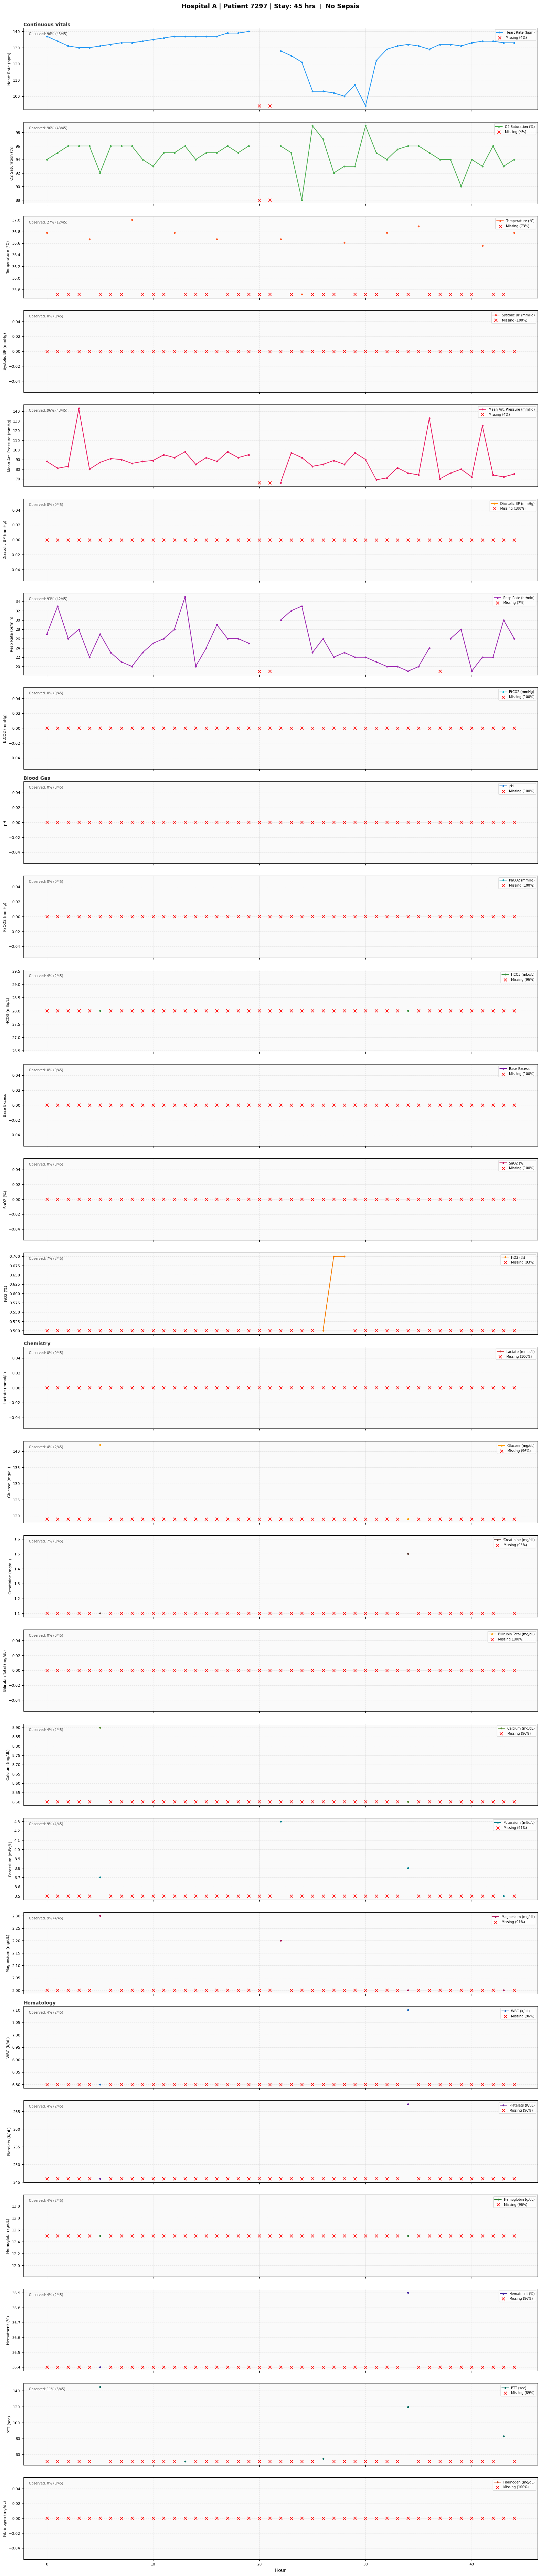

7297

In [10]:
# Random patient
plot_all_vitals(combined, hospital_name="Hospital A")

# # Specific patient
# plot_all_vitals(combined, hospital_name="Hospital A", patient_id=20411)


# # Different random seed
# plot_all_vitals(combined, hospital_name="Hospital B", seed=7)

In [11]:
def print_missingness(df, hospital_name="Hospital"):
    """
    Prints % missingness for every feature grouped by type.
    """
    feature_groups = {
        "Continuous Vitals": ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "EtCO2"],
        "Blood Gas":         ["pH", "PaCO2", "HCO3", "BaseExcess", "SaO2", "FiO2"],
        "Chemistry":         ["Lactate", "Glucose", "Creatinine", "Bilirubin_total",
                              "Calcium", "Potassium", "Magnesium", "Phosphate",
                              "Chloride", "BUN", "AST", "Alkalinephos",
                              "Bilirubin_direct", "TroponinI"],
        "Hematology":        ["WBC", "Platelets", "Hgb", "Hct", "PTT", "Fibrinogen"],
        "Demographics":      ["Age", "Gender", "ICULOS", "HospAdmTime", "Unit1", "Unit2"],
    }

    n_rows = df.shape[0]

    print(f"\n{'='*55}")
    print(f"  {hospital_name} - Missingness Report")
    print(f"  Rows: {n_rows:,} | Patients: {df['Patient_ID'].nunique():,}")
    print(f"{'='*55}")

    for group, cols in feature_groups.items():
        available = [c for c in cols if c in df.columns]
        if not available:
            continue
        print(f"\n-- {group}")
        print(f"   {'Feature':<20} {'% Missing':>10} {'% Observed':>12}")
        print(f"   {'-'*42}")
        for col in sorted(available, key=lambda c: df[c].isnull().mean(), reverse=True):
            pct_miss = df[col].isnull().mean() * 100
            pct_obs  = 100 - pct_miss
            print(f"   {col:<20} {pct_miss:>9.1f}%  {pct_obs:>10.1f}%")

    print(f"\n{'='*55}\n")

In [12]:
print_missingness(df_train, hospital_name="Hospital A")
print_missingness(df_test,  hospital_name="Hospital B")


  Hospital A - Missingness Report
  Rows: 790,215 | Patients: 20,336

-- Continuous Vitals
   Feature               % Missing   % Observed
   ------------------------------------------
   EtCO2                    100.0%         0.0%
   Temp                      66.2%        33.8%
   DBP                       48.1%        51.9%
   SBP                       15.2%        84.8%
   O2Sat                     12.0%        88.0%
   MAP                       10.2%        89.8%
   Resp                       9.8%        90.2%
   HR                         7.7%        92.3%

-- Blood Gas
   Feature               % Missing   % Observed
   ------------------------------------------
   SaO2                      95.0%         5.0%
   HCO3                      91.9%         8.1%
   PaCO2                     91.2%         8.8%
   BaseExcess                89.6%        10.4%
   pH                        88.5%        11.5%
   FiO2                      85.8%        14.2%

-- Chemistry
   Feature          

In [13]:
# -- Feature groups ------------------------------------------------------------
continuous_vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

demographics = ['Age', 'Gender', 'ICULOS', 'HospAdmTime']

# All features to keep
selected_cols = (['Patient_ID', 'Hour', 'SepsisLabel'] +
                 continuous_vitals + demographics)

# Check all columns exist
missing_cols = [col for col in selected_cols if col not in combined.columns]
if missing_cols:
    print(f"Warning: These columns are missing: {missing_cols}")
else:
    print(f"All {len(selected_cols)} columns found!")
    print(f"  Continuous vitals : {continuous_vitals}")
    print(f"  Demographics      : {demographics}")


def drop_patients_with_missing_vitals(df, hospital_name="Hospital"):
    """
    Drops any patient that has ALL values missing for any single
    continuous vital sign.
    """
    total_patients_before = df['Patient_ID'].nunique()
    total_rows_before     = df.shape[0]

    print(f"\n{'='*55}")
    print(f"  {hospital_name} - Patient Dropping Report")
    print(f"{'='*55}")
    print(f"\nBEFORE:")
    print(f"   Patients : {total_patients_before:,}")
    print(f"   Rows     : {total_rows_before:,}")

    print(f"\nPatients with 100% missing per vital:")
    patients_to_drop = set()
    drop_reason = {v: [] for v in continuous_vitals}

    for vital in continuous_vitals:
        fully_missing = df.groupby('Patient_ID')[vital].apply(
            lambda x: x.isnull().all()
        )
        bad_patients = fully_missing[fully_missing].index.tolist()
        drop_reason[vital] = bad_patients
        patients_to_drop.update(bad_patients)
        print(f"   {vital:10s} : {len(bad_patients):,} patients fully missing")

    print(f"\nPatients to drop : {len(patients_to_drop):,}")

    df_clean = df[~df['Patient_ID'].isin(patients_to_drop)].copy()

    total_patients_after = df_clean['Patient_ID'].nunique()
    total_rows_after     = df_clean.shape[0]
    sepsis_before = df[df['SepsisLabel'] == 1]['Patient_ID'].nunique()
    sepsis_after  = df_clean[df_clean['SepsisLabel'] == 1]['Patient_ID'].nunique()

    print(f"\nAFTER:")
    print(f"   Patients : {total_patients_after:,} "
          f"({total_patients_after/total_patients_before*100:.1f}% kept)")
    print(f"   Rows     : {total_rows_after:,} "
          f"({total_rows_after/total_rows_before*100:.1f}% kept)")
    print(f"   Dropped  : {total_patients_before - total_patients_after:,} patients")

    print(f"\nSepsis:")
    print(f"   Before : {sepsis_before:,}")
    print(f"   After  : {sepsis_after:,}")
    print(f"   Dropped: {sepsis_before - sepsis_after:,}")
    print(f"   Prevalence: {sepsis_after/total_patients_after*100:.2f}%")

    print(f"\nRemaining missingness:")
    for col in continuous_vitals:
        n_miss = df_clean[col].isnull().sum()
        pct    = n_miss / total_rows_after * 100
        print(f"   {col:10s} : {pct:.1f}% missing")

    print(f"\n{'='*55}\n")
    return df_clean


# -- Create the two datasets ---------------------------------------------------
df_hospitalA = df_train[selected_cols].copy()
df_hospitalB = df_test[selected_cols].copy()

# -- Drop patients with fully missing vitals -----------------------------------
df_hospitalA = drop_patients_with_missing_vitals(df_hospitalA, "Hospital A")
df_hospitalB = drop_patients_with_missing_vitals(df_hospitalB, "Hospital B")

# -- Save ----------------------------------------------------------------------
df_hospitalA.to_csv('hospitalA_vitals.csv', index=False)
df_hospitalB.to_csv('hospitalB_vitals.csv', index=False)

print("Saved: hospitalA_vitals.csv, hospitalB_vitals.csv")
print(f"   Hospital A: {df_hospitalA.shape[0]:,} rows, "
      f"{df_hospitalA['Patient_ID'].nunique():,} patients")
print(f"   Hospital B: {df_hospitalB.shape[0]:,} rows, "
      f"{df_hospitalB['Patient_ID'].nunique():,} patients")

All 14 columns found!
  Continuous vitals : ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
  Demographics      : ['Age', 'Gender', 'ICULOS', 'HospAdmTime']

  Hospital A - Patient Dropping Report

BEFORE:
   Patients : 20,336
   Rows     : 790,215

Patients with 100% missing per vital:
   HR         : 1 patients fully missing
   O2Sat      : 12 patients fully missing
   Temp       : 235 patients fully missing
   SBP        : 258 patients fully missing
   MAP        : 2 patients fully missing
   DBP        : 7,384 patients fully missing
   Resp       : 28 patients fully missing

Patients to drop : 7,599

AFTER:
   Patients : 12,737 (62.6% kept)
   Rows     : 525,433 (66.5% kept)
   Dropped  : 7,599 patients

Sepsis:
   Before : 1,790
   After  : 1,273
   Dropped: 517
   Prevalence: 9.99%

Remaining missingness:
   HR         : 6.1% missing
   O2Sat      : 9.0% missing
   Temp       : 61.1% missing
   SBP        : 13.5% missing
   MAP        : 7.2% missing
   DBP        : 23.2% mis

## Plotting function: sepsis vs. non-sepsis patient comparison

Diagnostic visualisation used to inspect raw vital sign trajectories for individual patients.

For each hospital (A and B) the function:

1. Selects two random patients, one who developed sepsis at some point (`SepsisLabel = 1`) and one who never did.
2. Prints a short report for each patient: patient ID, hospital, number of hours recorded, sepsis status, and the percentage of missing values for each vital (HR, DBP, SBP, MAP, Resp).
3. Plots a 5x2 grid of time series. The left column shows the sepsis patient's five vitals over time, the right column shows the non-sepsis patient's. Missing hours are marked in red, and the sepsis patient's panels are shaded over the interval where `SepsisLabel = 1` is active.

The purpose is an exploratory sanity check prior to the formal missingness analysis: to confirm what raw ICU vitals look like for a single patient, to compare a developing-sepsis trajectory against a non-sepsis one (e.g. whether HR rises or MAP drops), and to gauge the amount of missing data within individual records before quantifying it across the full cohort.

The function is read-only: it does not modify or save any data, so it can be run at any stage of the pipeline. It is also useful after sparsity filtering and imputation, to verify that the cleaned data remains clinically plausible.

In [14]:
def plot_patient_timeseries(df, hospital_name="Hospital"):
    """
    Plots all vital sign time series for one random sepsis patient 
    and one random healthy patient side by side.
    Warns if any sensor data is missing for either patient.
    """
    vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
    labels = {
        'HR'  : 'Heart Rate (bpm)',
        'O2Sat': 'O2 Saturation (%)',
        'Temp' : 'Temperature (°C)',
        'SBP'  : 'Systolic BP (mmHg)',
        'MAP'  : 'Mean Arterial Pressure (mmHg)',
        'DBP'  : 'Diastolic BP (mmHg)',
        'Resp' : 'Respiratory Rate (breaths/min)',
    }
    colors = ['#2196F3', '#4CAF50', '#FF5722', '#F44336', '#E91E63', '#FF9800', '#9C27B0']

    # -- Select one sepsis patient and one healthy patient ------------------
    sepsis_patients  = df.groupby('Patient_ID')['SepsisLabel'].max()
    sepsis_ids       = sepsis_patients[sepsis_patients == 1].index.tolist()
    healthy_ids      = sepsis_patients[sepsis_patients == 0].index.tolist()

    random_sepsis    = random.choice(sepsis_ids)
    random_healthy   = random.choice(healthy_ids)

    patient_dict = {
        'Sepsis Patient' : df[df['Patient_ID'] == random_sepsis ].sort_values('Hour'),
        'Healthy Patient': df[df['Patient_ID'] == random_healthy].sort_values('Hour'),
    }

    # -- Print summary + warnings for each patient --------------------------
    for patient_type, patient_data in patient_dict.items():
        pid = patient_data['Patient_ID'].iloc[0]
        print(f"{'='*50}")
        print(f"Type       : {patient_type}")
        print(f"Patient ID : {pid}")
        print(f"Hospital   : {hospital_name}")
        print(f"Hours      : {len(patient_data)}")
        print(f"Sepsis     : {'Yes' if patient_data['SepsisLabel'].max() == 1 else 'No'}")
        print(f"{'-'*50}")
        has_warning = False
        for vital in vitals:
            missing_count = patient_data[vital].isnull().sum()
            missing_pct   = (missing_count / len(patient_data)) * 100
            if missing_count > 0:
                print(f"WARNING: {vital} has {missing_count} missing values ({missing_pct:.1f}% of hours)")
                has_warning = True
        if not has_warning:
            print("No missing values for this patient")
        print(f"{'='*50}\n")

    # -- Plot: rows = vitals, cols = [sepsis, healthy] ----------------------
    fig, axes = plt.subplots(len(vitals), 2, figsize=(18, 14), sharex='col')
    fig.suptitle(f'{hospital_name} - Sepsis vs Healthy Patient Comparison',
                 fontsize=15, fontweight='bold', y=1.01)

    col_titles = {
        0: f'Sepsis Patient (ID: {random_sepsis})',
        1: f'Healthy Patient (ID: {random_healthy})'
    }

    for col, (patient_type, patient_data) in enumerate(patient_dict.items()):
        for row, (vital, color) in enumerate(zip(vitals, colors)):
            ax = axes[row, col]

            # Plot vital sign
            ax.plot(patient_data['Hour'], patient_data[vital],
                    color=color, linewidth=1.5, marker='o', markersize=3)

            # Mark missing values on x-axis
            missing_hours = patient_data[patient_data[vital].isnull()]['Hour']
            if not missing_hours.empty:
                ymin = patient_data[vital].min()
                ax.scatter(missing_hours, [ymin] * len(missing_hours),
                           color='red', marker='x', s=50, label='Missing', zorder=5)
                ax.legend(loc='upper right', fontsize=7)

            # Shade sepsis region (only relevant for sepsis patient)
            sepsis_hours = patient_data[patient_data['SepsisLabel'] == 1]['Hour']
            if not sepsis_hours.empty:
                ax.axvspan(sepsis_hours.min(), sepsis_hours.max(),
                           alpha=0.15, color='red', label='Sepsis period')
                ax.legend(loc='upper right', fontsize=7)

            # Labels and styling
            if row == 0:
                ax.set_title(col_titles[col], fontsize=11, fontweight='bold',
                             color='red' if col == 0 else 'green')
            if col == 0:
                ax.set_ylabel(labels[vital], fontsize=8)
            if row == len(vitals) - 1:
                ax.set_xlabel('Hour', fontsize=9)

            ax.grid(True, alpha=0.3)
            ax.set_facecolor('#fff5f5' if col == 0 else '#f5fff5')

    plt.tight_layout()
    plt.show()

Type       : Sepsis Patient
Patient ID : 14092
Hospital   : Hospital A
Hours      : 109
Sepsis     : Yes
--------------------------------------------------

Type       : Healthy Patient
Patient ID : 13272
Hospital   : Hospital A
Hours      : 44
Sepsis     : No
--------------------------------------------------



C:\Users\firas.hindawi.CCM\AppData\Local\Temp\ipykernel_31656\1855920012.py:98: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\firas.hindawi.CCM\AppData\Local\Temp\ipykernel_31656\1855920012.py:98: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\firas.hindawi.CCM\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\firas.hindawi.CCM\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


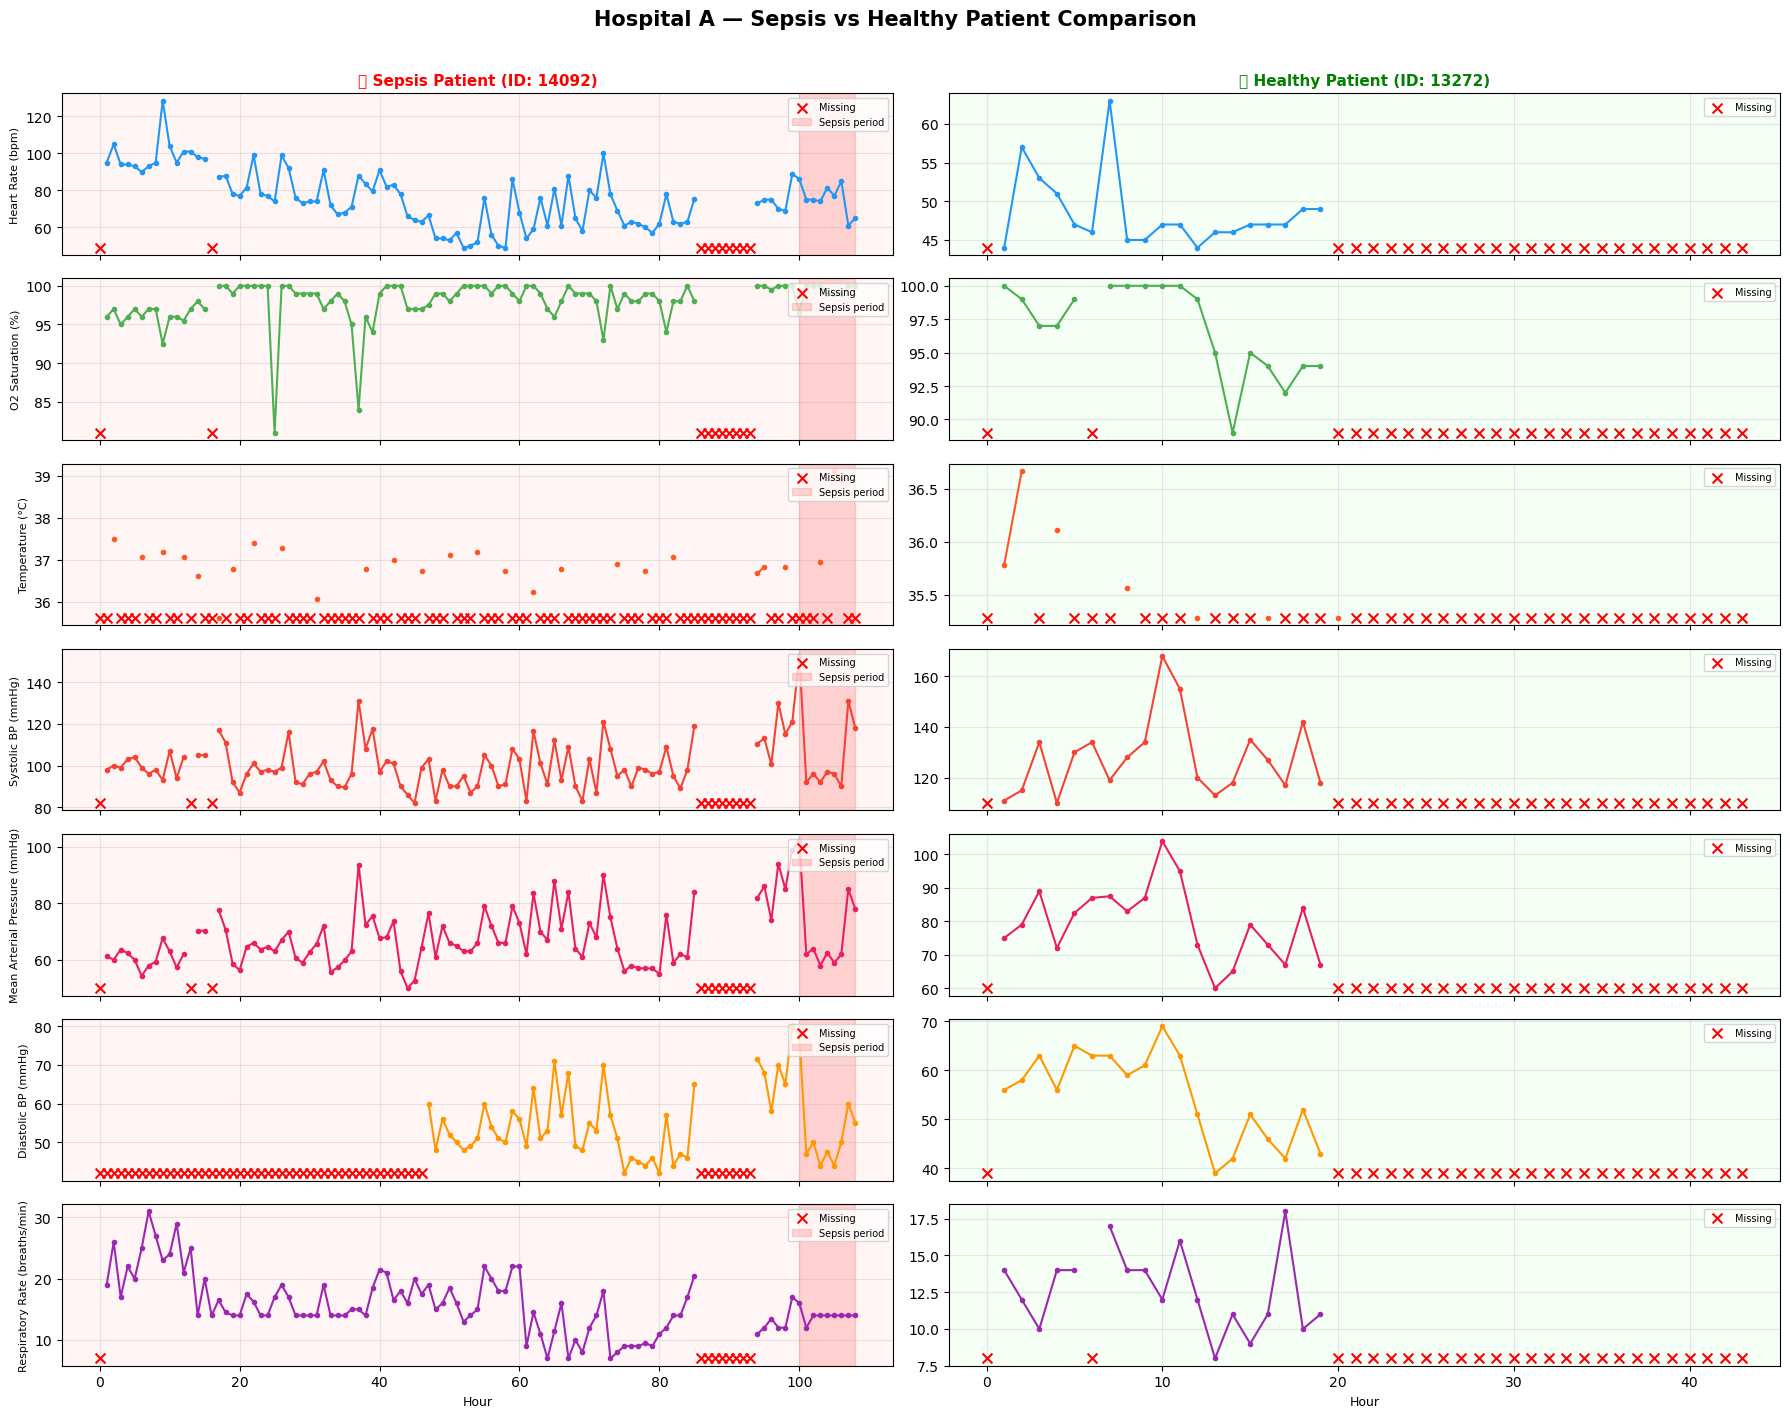

Type       : Sepsis Patient
Patient ID : 115190
Hospital   : Hospital B
Hours      : 13
Sepsis     : Yes
--------------------------------------------------

Type       : Healthy Patient
Patient ID : 119764
Hospital   : Hospital B
Hours      : 21
Sepsis     : No
--------------------------------------------------



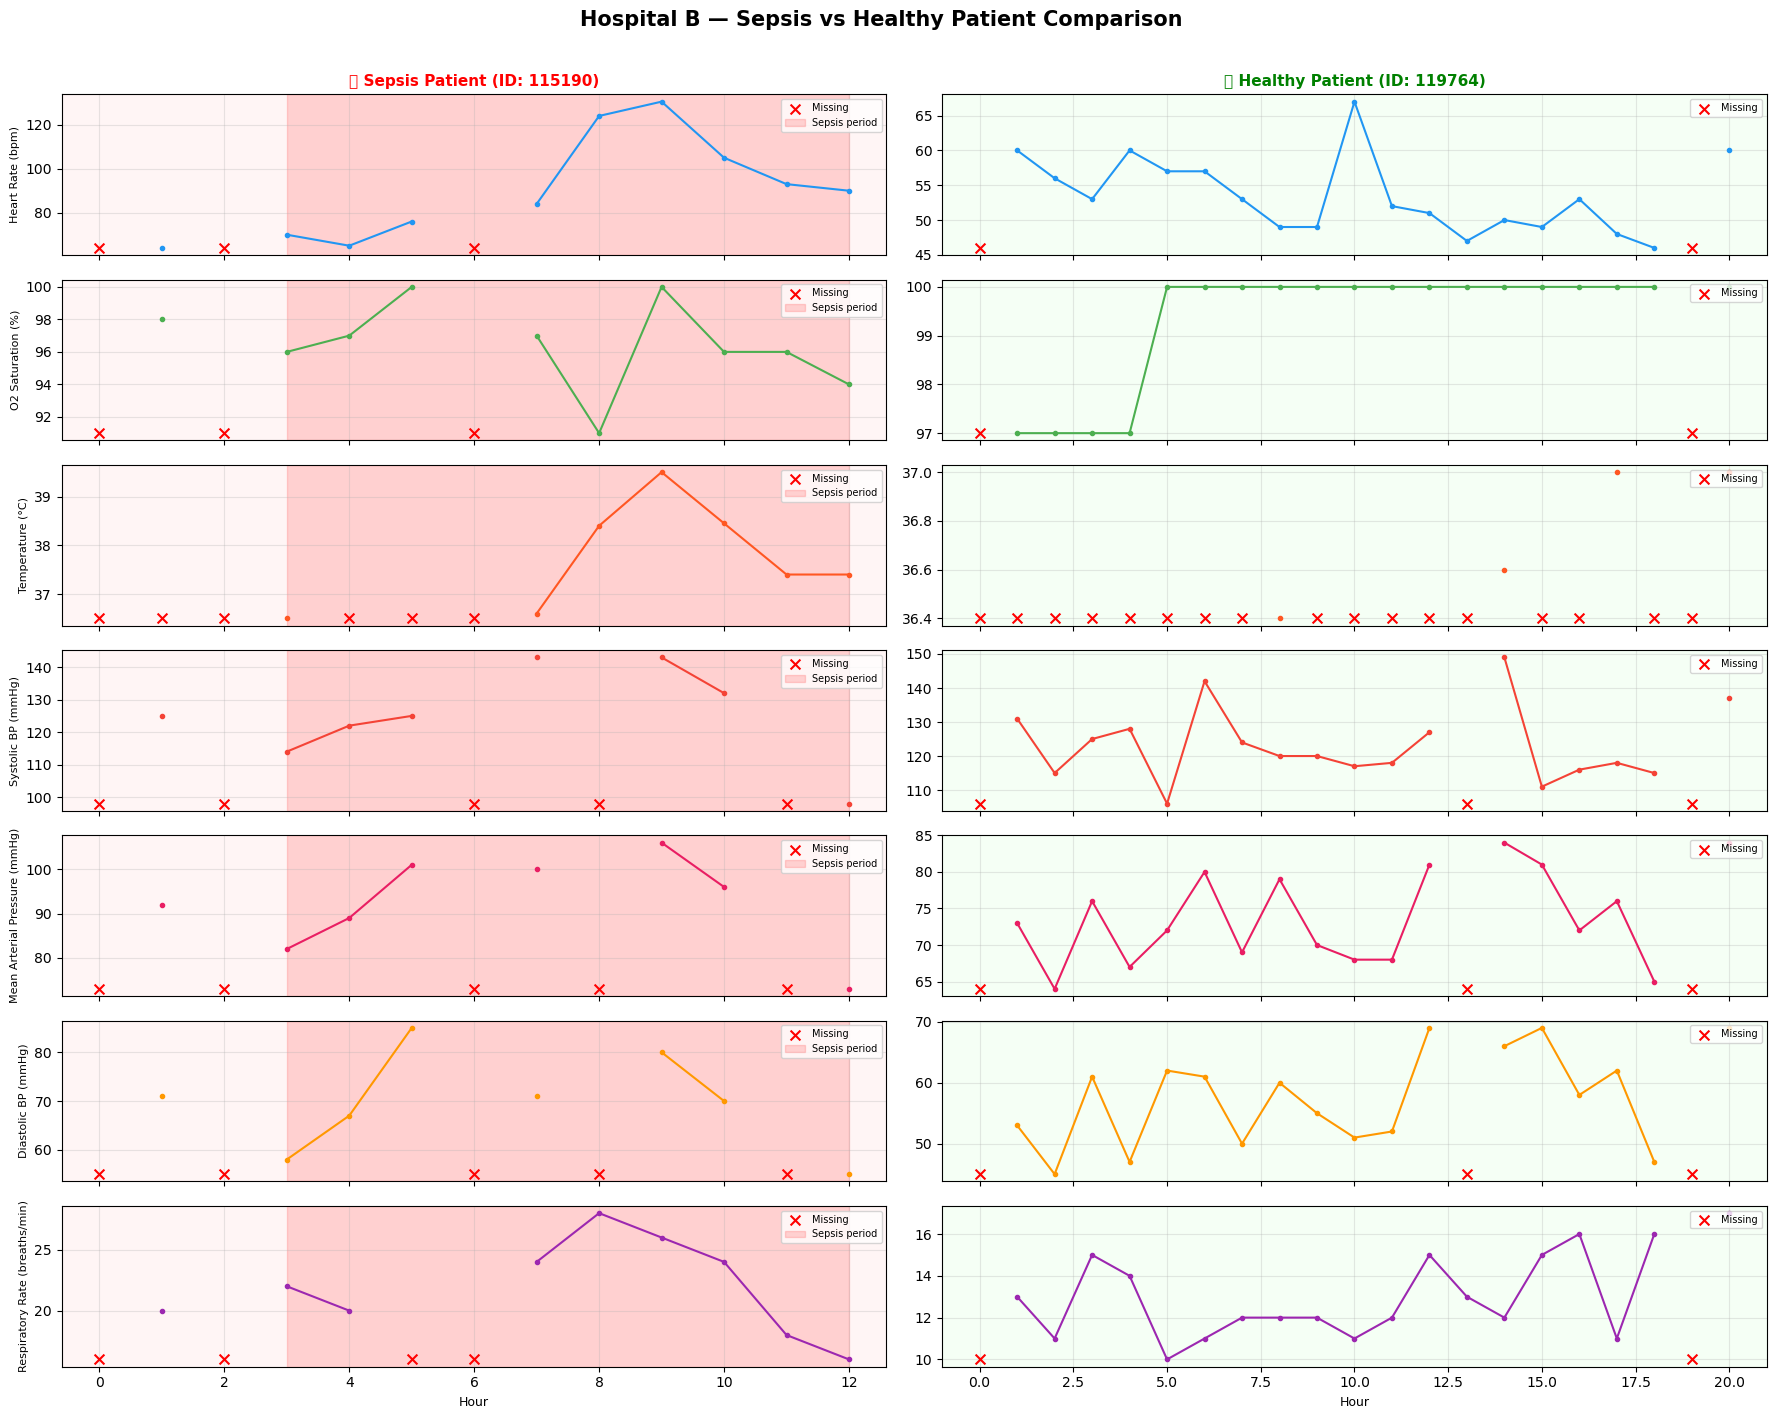

In [15]:
# Usage
plot_patient_timeseries(df_hospitalA, hospital_name="Hospital A")
plot_patient_timeseries(df_hospitalB, hospital_name="Hospital B")

## Check LEADING & TRAILING consecutive datapoints missigness problem
For each patient, trims all 5 vitals to the common window where every vital has at least one valid reading nearby - i.e. trims off leading/trailing stretches where any single sensor wasn't active yet or had stopped recording.

Patients where vitals never overlap (no valid common window) are dropped.

## Check LEADING & TRAILING consecutive datapoints missigness problem

In [16]:
def trim_to_common_valid_window(df, hospital_name="Hospital", min_window_length=6):
    """
    Trims each patient to the common window where all vitals have valid data.
    Drops patients where the resulting window is shorter than min_window_length hours
    (too short to be a usable time series).
    """
    vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

    total_patients_before = df['Patient_ID'].nunique()
    total_rows_before      = df.shape[0]

    print(f"\n{'='*60}")
    print(f"  {hospital_name} - Trim to Common Valid Window")
    print(f"  (Minimum usable window: {min_window_length} hours)")
    print(f"{'='*60}")

    dropped_patients = []
    trimmed_frames = []
    patients_actually_trimmed = 0

    for pid, group in df.groupby('Patient_ID'):
        group = group.sort_values('Hour').reset_index(drop=True)
        n = len(group)

        first_valid = {}
        last_valid  = {}
        for vital in vitals:
            valid_idx = group.index[group[vital].notna()]
            if len(valid_idx) == 0:
                first_valid[vital] = None
                last_valid[vital]  = None
            else:
                first_valid[vital] = valid_idx[0]
                last_valid[vital]  = valid_idx[-1]

        starts = [v for v in first_valid.values() if v is not None]
        ends   = [v for v in last_valid.values()  if v is not None]

        if not starts or not ends:
            dropped_patients.append(pid)
            continue

        window_start = max(starts)
        window_end   = min(ends)
        window_length = window_end - window_start + 1

        # -- NEW: enforce minimum window length -------------------------
        if window_start > window_end or window_length < min_window_length:
            dropped_patients.append(pid)
            continue

        trimmed = group.iloc[window_start:window_end + 1].reset_index(drop=True)
        trimmed['Hour'] = range(len(trimmed))

        if window_start > 0 or window_end < n - 1:
            patients_actually_trimmed += 1

        trimmed_frames.append(trimmed)

    df_trimmed = pd.concat(trimmed_frames, ignore_index=True) if trimmed_frames else df.iloc[0:0].copy()

    total_patients_after = df_trimmed['Patient_ID'].nunique()
    total_rows_after      = df_trimmed.shape[0]

    sepsis_before = df[df['SepsisLabel'] == 1]['Patient_ID'].nunique()
    sepsis_after  = df_trimmed[df_trimmed['SepsisLabel'] == 1]['Patient_ID'].nunique()

    print(f"\nOverall Summary:")
    print(f"   Total patients before        : {total_patients_before:>7}")
    print(f"   Patients dropped (no overlap or too short) : {len(dropped_patients):>7} "
          f"({len(dropped_patients)/total_patients_before*100:.2f}%)")
    print(f"   Patients remaining           : {total_patients_after:>7} "
          f"({total_patients_after/total_patients_before*100:.2f}%)")
    print(f"   Patients actually trimmed    : {patients_actually_trimmed:>7}")
    print(f"\n   Rows before                  : {total_rows_before:>9,}")
    print(f"   Rows after                   : {total_rows_after:>9,} "
          f"({total_rows_after/total_rows_before*100:.1f}% kept)")
    print(f"\nSepsis Patients:")
    print(f"   Before  : {sepsis_before}")
    print(f"   After   : {sepsis_after}")
    print(f"   Dropped : {sepsis_before - sepsis_after}")
    print(f"{'='*60}\n")

    return df_trimmed, dropped_patients


# -- Re-run with minimum window length enforced ---------------------------------
df_hospitalA_windowed, dropped_A = trim_to_common_valid_window(df_hospitalA, hospital_name="Hospital A", min_window_length=6)
df_hospitalB_windowed, dropped_B = trim_to_common_valid_window(df_hospitalB, hospital_name="Hospital B", min_window_length=6)


  Hospital A - Trim to Common Valid Window
  (Minimum usable window: 6 hours)

Overall Summary:
   Total patients before        :   12737
   Patients dropped (no overlap or too short) :    1060 (8.32%)
   Patients remaining           :   11677 (91.68%)
   Patients actually trimmed    :   10795

   Rows before                  :   525,433
   Rows after                   :   384,546 (73.2% kept)

Sepsis Patients:
   Before  : 1273
   After   : 1000
   Dropped : 273


  Hospital B - Trim to Common Valid Window
  (Minimum usable window: 6 hours)

Overall Summary:
   Total patients before        :   19811
   Patients dropped (no overlap or too short) :     957 (4.83%)
   Patients remaining           :   18854 (95.17%)
   Patients actually trimmed    :   18583

   Rows before                  :   757,492
   Rows after                   :   641,225 (84.7% kept)

Sepsis Patients:
   Before  : 1118
   After   : 857
   Dropped : 261



Type       : Sepsis Patient
Patient ID : 5053
Hospital   : Windowed Hospital A
Hours      : 11
Sepsis     : Yes
--------------------------------------------------

Type       : Healthy Patient
Patient ID : 3501
Hospital   : Windowed Hospital A
Hours      : 41
Sepsis     : No
--------------------------------------------------



C:\Users\firas.hindawi.CCM\AppData\Local\Temp\ipykernel_31656\1855920012.py:98: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\firas.hindawi.CCM\AppData\Local\Temp\ipykernel_31656\1855920012.py:98: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


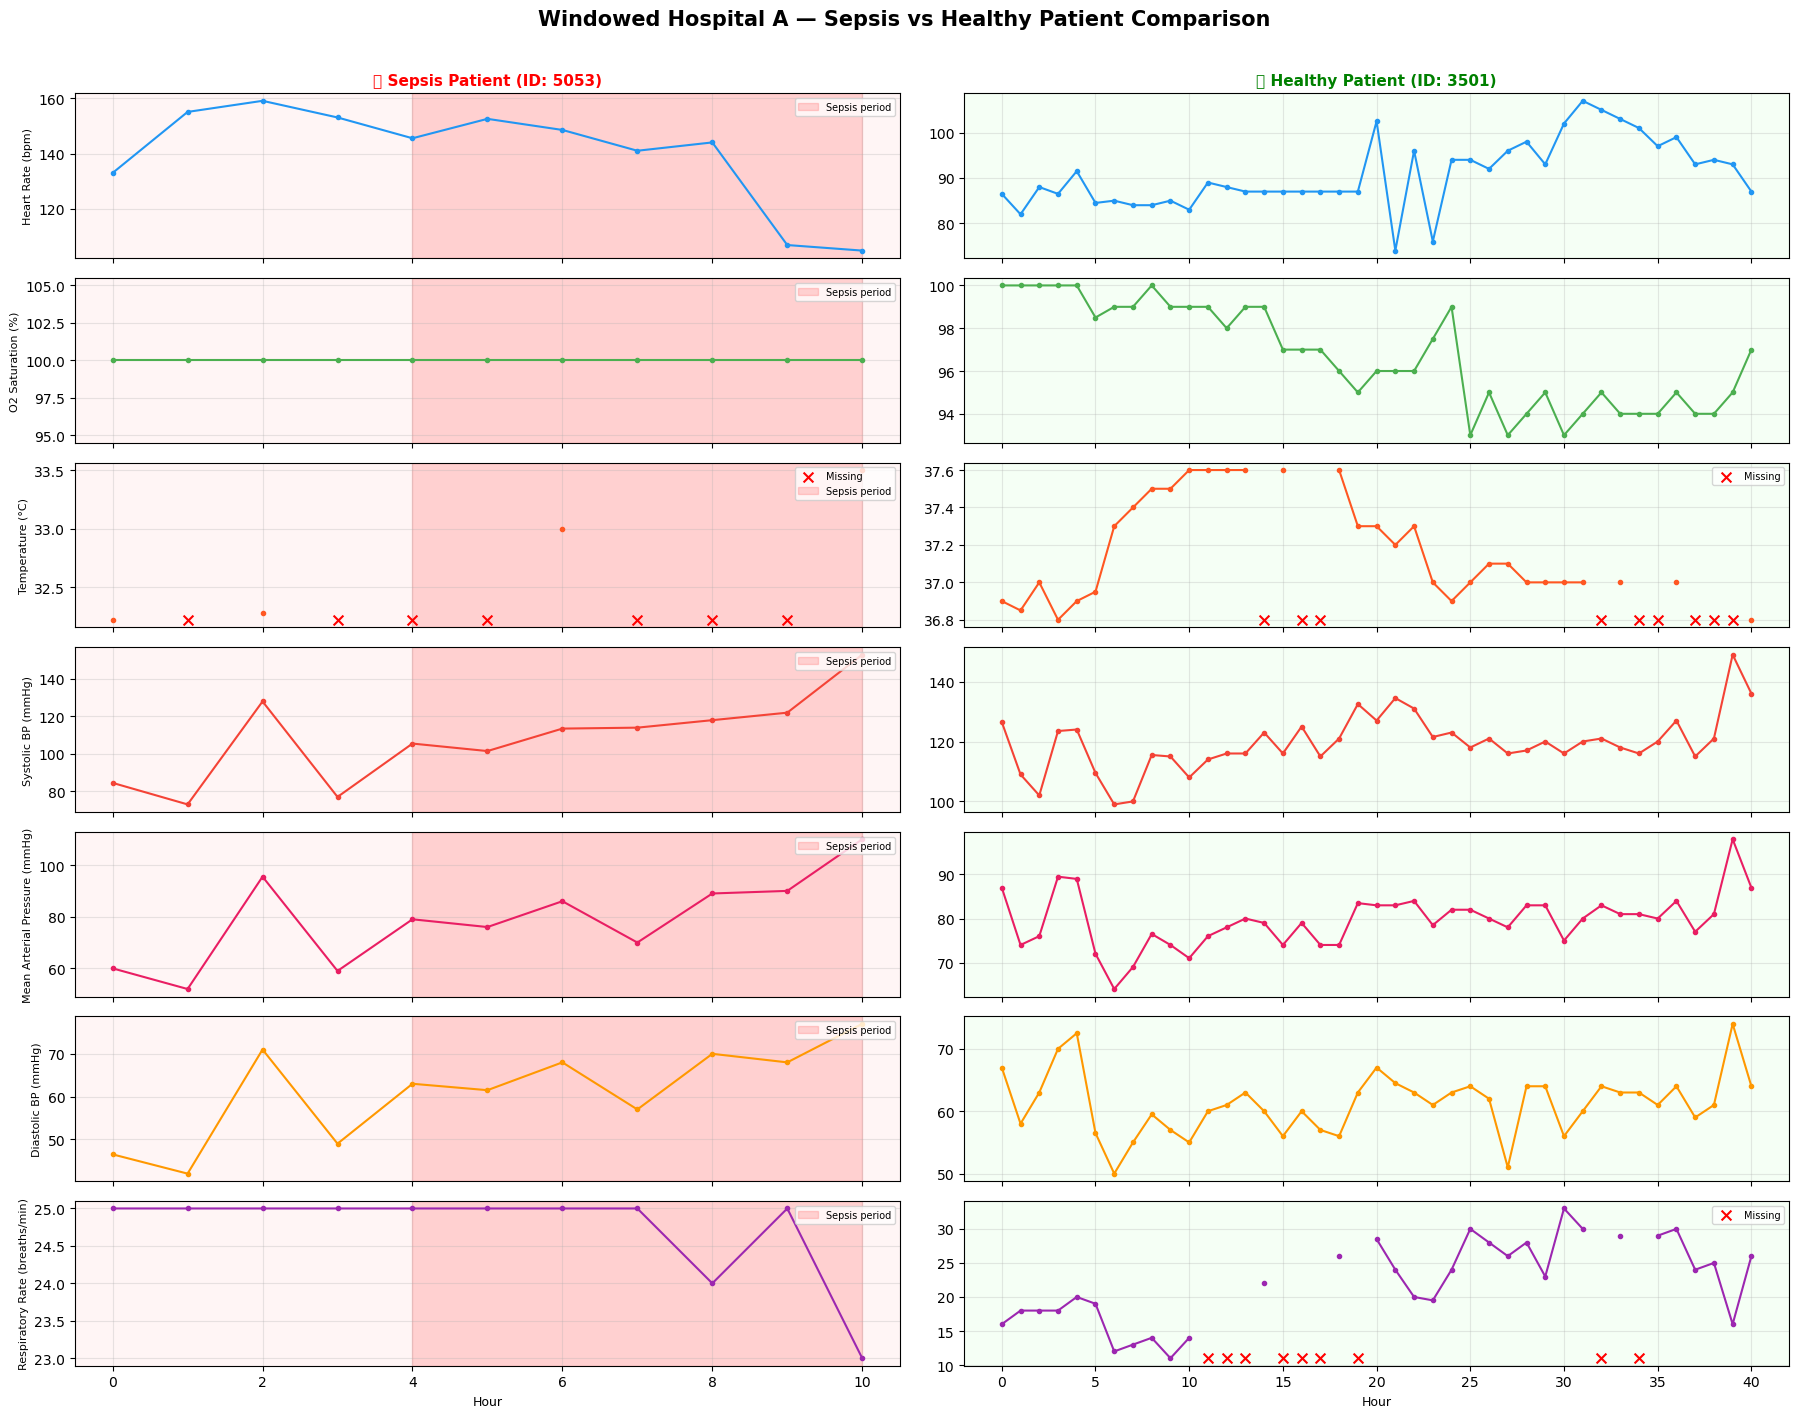

Type       : Sepsis Patient
Patient ID : 116392
Hospital   : Windowed Hospital B
Hours      : 134
Sepsis     : Yes
--------------------------------------------------

Type       : Healthy Patient
Patient ID : 104223
Hospital   : Windowed Hospital B
Hours      : 53
Sepsis     : No
--------------------------------------------------



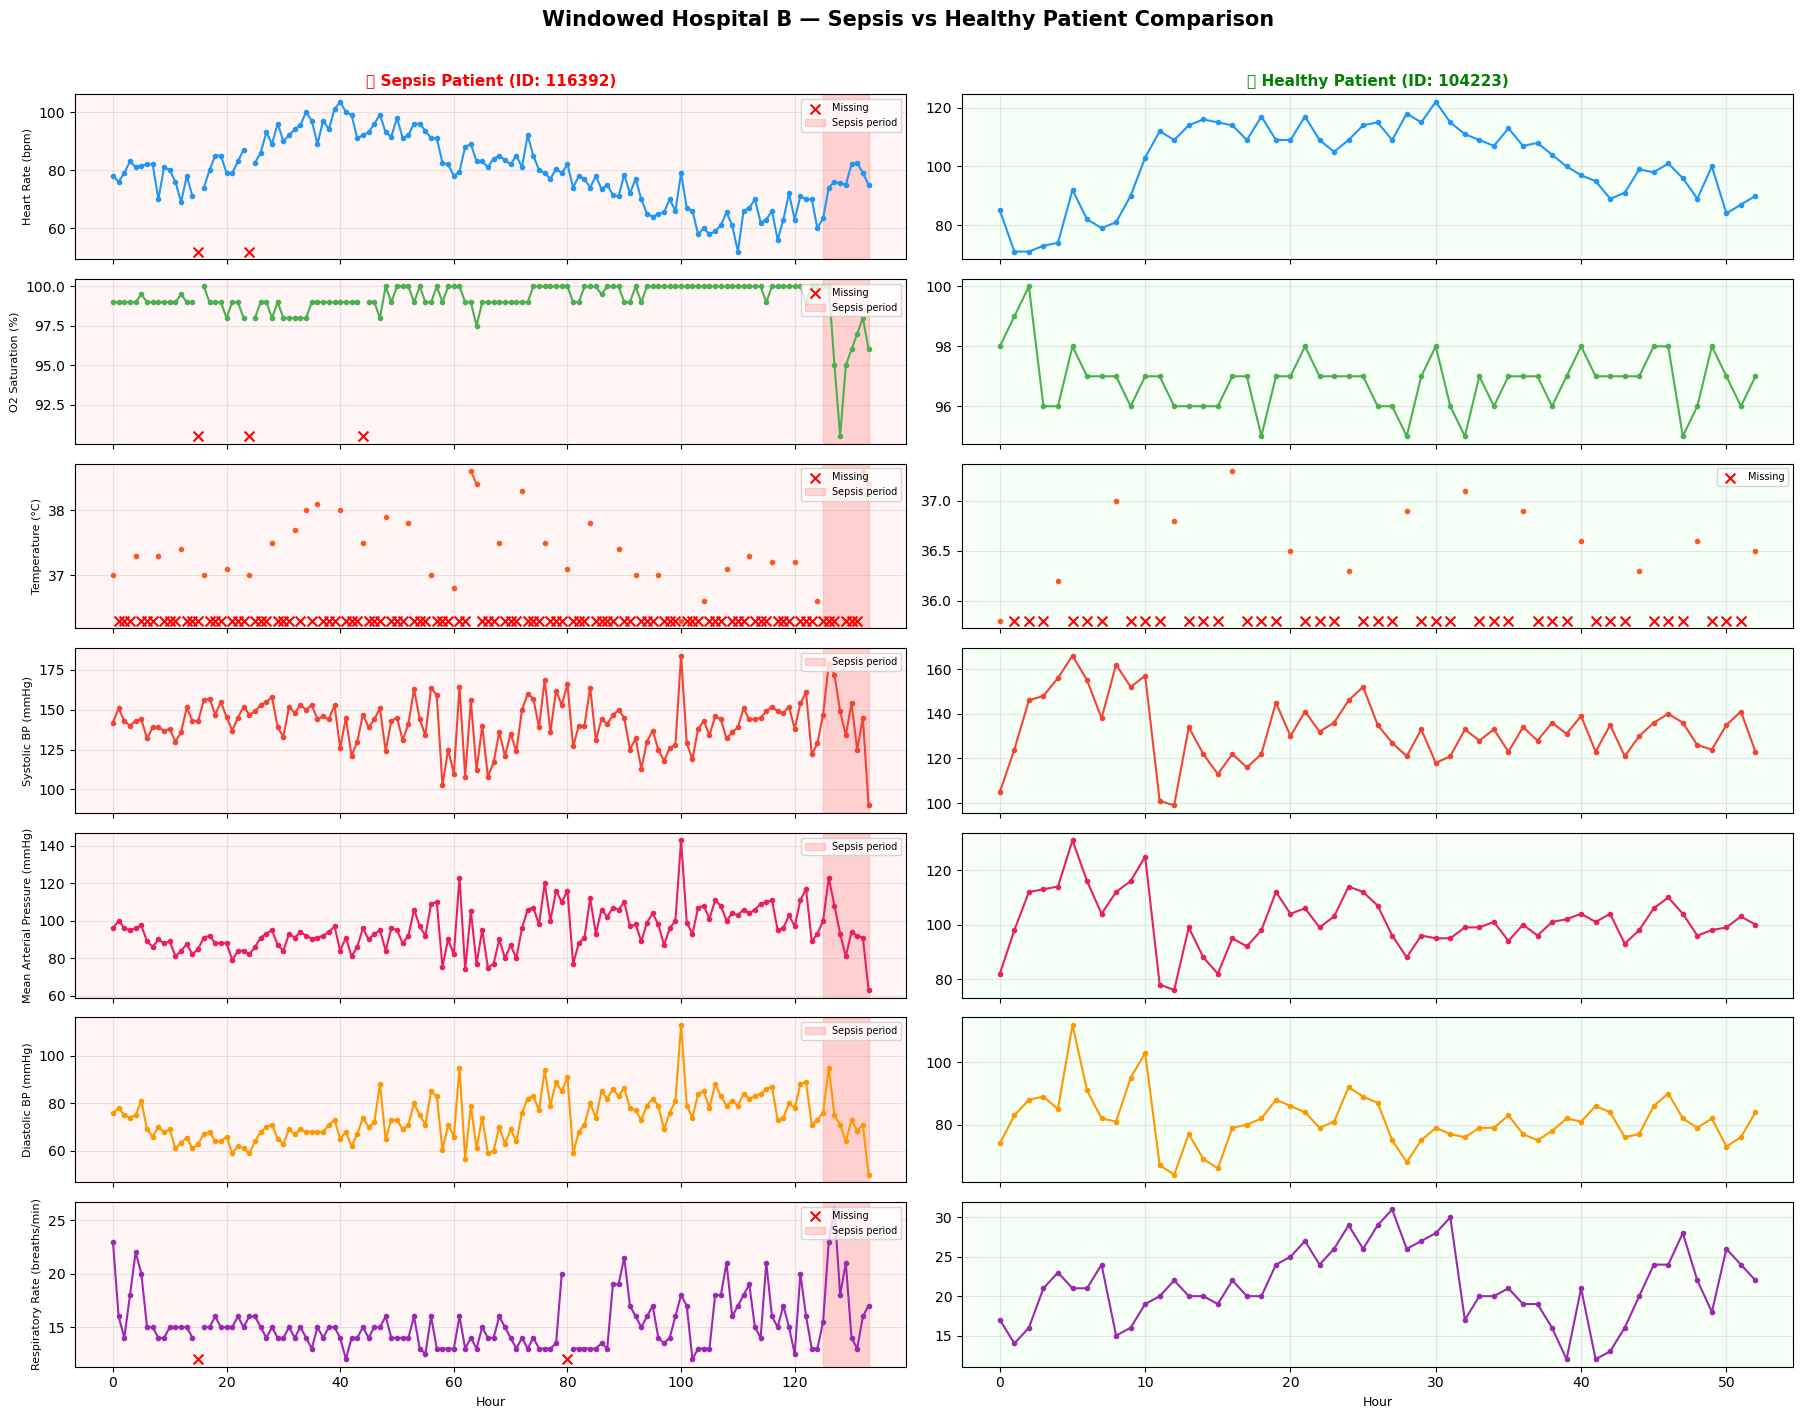

In [17]:
plot_patient_timeseries(df_hospitalA_windowed, hospital_name="Windowed Hospital A")
plot_patient_timeseries(df_hospitalB_windowed, hospital_name="Windowed Hospital B")

In [18]:
def diagnose_remaining_consecutive_gaps(df, hospital_name="Hospital", thresholds=(5, 10, 20)):
    """
    Diagnostic-only check (no dropping) of remaining consecutive gaps
    after trimming to the common valid window. Reports, per vital,
    how many patients still have internal gaps of various lengths.
    """
    vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

    print(f"\n{'='*65}")
    print(f"  {hospital_name} - Remaining Consecutive Gap Diagnostic (post-trim)")
    print(f"{'='*65}")

    total_patients = df['Patient_ID'].nunique()

    def longest_run(is_null_array):
        max_run = 0
        current = 0
        for val in is_null_array:
            if val:
                current += 1
                max_run = max(max_run, current)
            else:
                current = 0
        return max_run

    # -- Per-patient, per-vital longest consecutive gap ------------------
    longest_gaps = {v: {} for v in vitals}
    for pid, group in df.groupby('Patient_ID'):
        group = group.sort_values('Hour')
        for vital in vitals:
            is_null = group[vital].isnull().values
            longest_gaps[vital][pid] = longest_run(is_null)

    # -- Report per vital, per threshold (no dropping) --------------------
    print(f"\nPatients with longest internal gap >= threshold (any vital):")
    print(f"   {'Vital':<6}", end="")
    for t in thresholds:
        print(f"{f'>={t}hrs':>10}", end="")
    print()
    print(f"   {'-'*(6 + 10*len(thresholds))}")

    patients_over_thresh = {t: set() for t in thresholds}

    for vital in vitals:
        gaps = pd.Series(longest_gaps[vital])
        row = f"   {vital:<6}"
        for t in thresholds:
            bad = gaps[gaps >= t]
            row += f"{len(bad):>10}"
            patients_over_thresh[t].update(bad.index.tolist())
        print(row)

    # -- Overall: how many UNIQUE patients affected at each threshold -----
    print(f"\nUnique patients affected (any vital) by threshold:")
    for t in thresholds:
        n = len(patients_over_thresh[t])
        print(f"   >= {t:>3}hrs in any vital : {n:>6} patients ({n/total_patients*100:.2f}%)")

    # -- Distribution table (same style as before, for visual reference) --
    print(f"\nLongest internal gap distribution per vital:")
    print(f"   {'Vital':<6} {'0-4hrs':>8} {'5-10hrs':>9} {'10-20hrs':>10} {'>20hrs':>8}")
    print(f"   {'-'*45}")
    for vital in vitals:
        gaps = pd.Series(longest_gaps[vital])
        b1 = (gaps < 5).sum()
        b2 = ((gaps >= 5) & (gaps <= 10)).sum()
        b3 = ((gaps > 10) & (gaps <= 20)).sum()
        b4 = (gaps > 20).sum()
        print(f"   {vital:<6} {b1:>8} {b2:>9} {b3:>10} {b4:>8}")

    print(f"\nNo patients were dropped - this is informational only.")
    print(f"   Use this to decide if imputation alone is sufficient, or if")
    print(f"   a stricter max_gap / different strategy is needed for outliers.")
    print(f"{'='*65}\n")

    return longest_gaps


# -- Run on the windowed (edge-trimmed) data ------------------------------------
gaps_A = diagnose_remaining_consecutive_gaps(df_hospitalA_windowed, hospital_name="Hospital A")
gaps_B = diagnose_remaining_consecutive_gaps(df_hospitalB_windowed, hospital_name="Hospital B")


  Hospital A - Remaining Consecutive Gap Diagnostic (post-trim)

Patients with longest internal gap >= threshold (any vital):
   Vital     >=5hrs   >=10hrs   >=20hrs
   ------------------------------------
   HR           288        40        16
   O2Sat        487        81        21
   Temp        3332       267        58
   SBP          346        71        34
   MAP          319        51        17
   DBP          446       143        72
   Resp         392        86        25

Unique patients affected (any vital) by threshold:
   >=   5hrs in any vital :   3571 patients (30.58%)
   >=  10hrs in any vital :    445 patients (3.81%)
   >=  20hrs in any vital :    126 patients (1.08%)

Longest internal gap distribution per vital:
   Vital    0-4hrs   5-10hrs   10-20hrs   >20hrs
   ---------------------------------------------
   HR        11389       251         22       15
   O2Sat     11190       417         49       21
   Temp       8345      3136        142       54
   SBP       

In [21]:
def get_patients_with_consecutive_gap(df, threshold=20, vitals=None):
    """
    Returns a filtered dataframe containing only the patients who have
    a longest internal consecutive gap >= threshold in ANY vital.
    Useful for feeding into plot_patient_timeseries() to visually inspect
    these specific cases.
    """
    if vitals is None:
        vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

    def longest_run(is_null_array):
        max_run = 0
        current = 0
        for val in is_null_array:
            if val:
                current += 1
                max_run = max(max_run, current)
            else:
                current = 0
        return max_run

    flagged_patients = set()

    for pid, group in df.groupby('Patient_ID'):
        group = group.sort_values('Hour')
        for vital in vitals:
            is_null = group[vital].isnull().values
            if longest_run(is_null) >= threshold:
                flagged_patients.add(pid)
                break  # no need to check other vitals once flagged

    df_flagged = df[df['Patient_ID'].isin(flagged_patients)].copy()

    print(f"Patients with >= {threshold}hr consecutive gap in any vital: {len(flagged_patients)}")
    print(f"Rows in returned dataset: {df_flagged.shape[0]:,}")

    return df_flagged
    

In [23]:
def drop_patients_with_long_gap(df, hospital_name="Hospital", threshold=20):
    """
    Drops patients with a longest internal consecutive gap >= threshold
    in any vital. Reports before/after stats.
    """
    vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

    flagged = get_patients_with_consecutive_gap(df, threshold=threshold, vitals=vitals)
    flagged_ids = flagged['Patient_ID'].unique()

    total_before = df['Patient_ID'].nunique()
    df_clean = df[~df['Patient_ID'].isin(flagged_ids)].copy()
    total_after = df_clean['Patient_ID'].nunique()

    sepsis_before = df[df['SepsisLabel'] == 1]['Patient_ID'].nunique()
    sepsis_after  = df_clean[df_clean['SepsisLabel'] == 1]['Patient_ID'].nunique()

    print(f"\n{hospital_name} - Drop patients with >= {threshold}hr consecutive gap")
    print(f"   Patients before : {total_before}")
    print(f"   Patients dropped: {len(flagged_ids)} ({len(flagged_ids)/total_before*100:.2f}%)")
    print(f"   Patients after  : {total_after}")
    print(f"   Sepsis dropped  : {sepsis_before - sepsis_after}")

    return df_clean


GAP_DROP_THRESHOLD = 20

df_hospitalA_final = drop_patients_with_long_gap(df_hospitalA_windowed, hospital_name="Hospital A", threshold=GAP_DROP_THRESHOLD)
df_hospitalB_final = drop_patients_with_long_gap(df_hospitalB_windowed, hospital_name="Hospital B", threshold=GAP_DROP_THRESHOLD)

Patients with >= 20hr consecutive gap in any vital: 126
Rows in returned dataset: 10,223

Hospital A - Drop patients with >= 20hr consecutive gap
   Patients before : 11677
   Patients dropped: 126 (1.08%)
   Patients after  : 11551
   Sepsis dropped  : 39
Patients with >= 20hr consecutive gap in any vital: 132
Rows in returned dataset: 8,110

Hospital B - Drop patients with >= 20hr consecutive gap
   Patients before : 18854
   Patients dropped: 132 (0.70%)
   Patients after  : 18722
   Sepsis dropped  : 27


Type       : Sepsis Patient
Patient ID : 4824
Hospital   : Hospital A (>=20hr gap patients)
Hours      : 105
Sepsis     : Yes
--------------------------------------------------

Type       : Healthy Patient
Patient ID : 18391
Hospital   : Hospital A (>=20hr gap patients)
Hours      : 24
Sepsis     : No
--------------------------------------------------



C:\Users\firas.hindawi.CCM\AppData\Local\Temp\ipykernel_31656\1855920012.py:98: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\firas.hindawi.CCM\AppData\Local\Temp\ipykernel_31656\1855920012.py:98: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


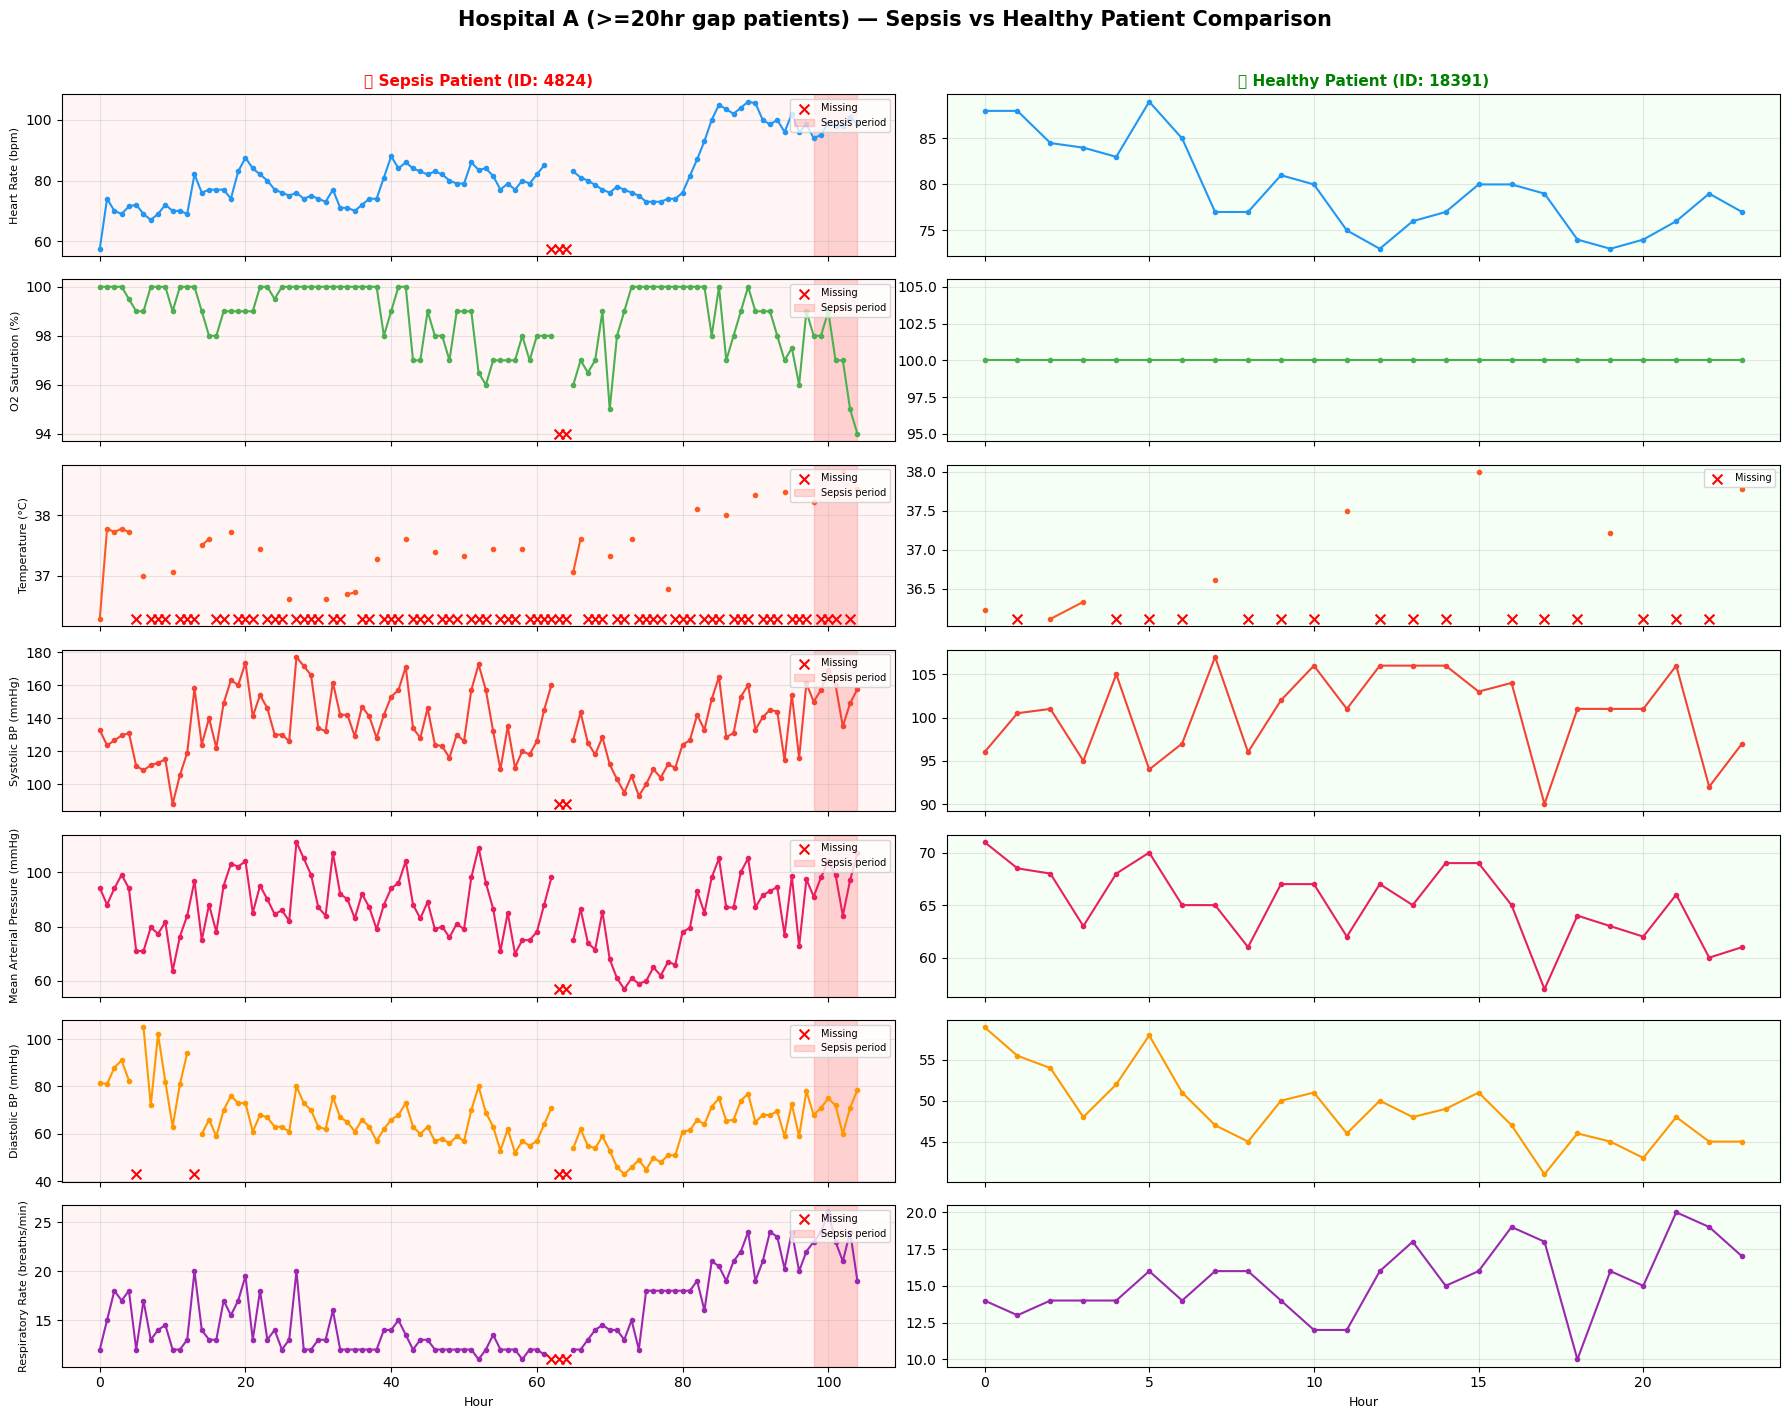

Type       : Sepsis Patient
Patient ID : 100946
Hospital   : Hospital B (>=20hr gap patients)
Hours      : 313
Sepsis     : Yes
--------------------------------------------------

Type       : Healthy Patient
Patient ID : 104965
Hospital   : Hospital B (>=20hr gap patients)
Hours      : 45
Sepsis     : No
--------------------------------------------------



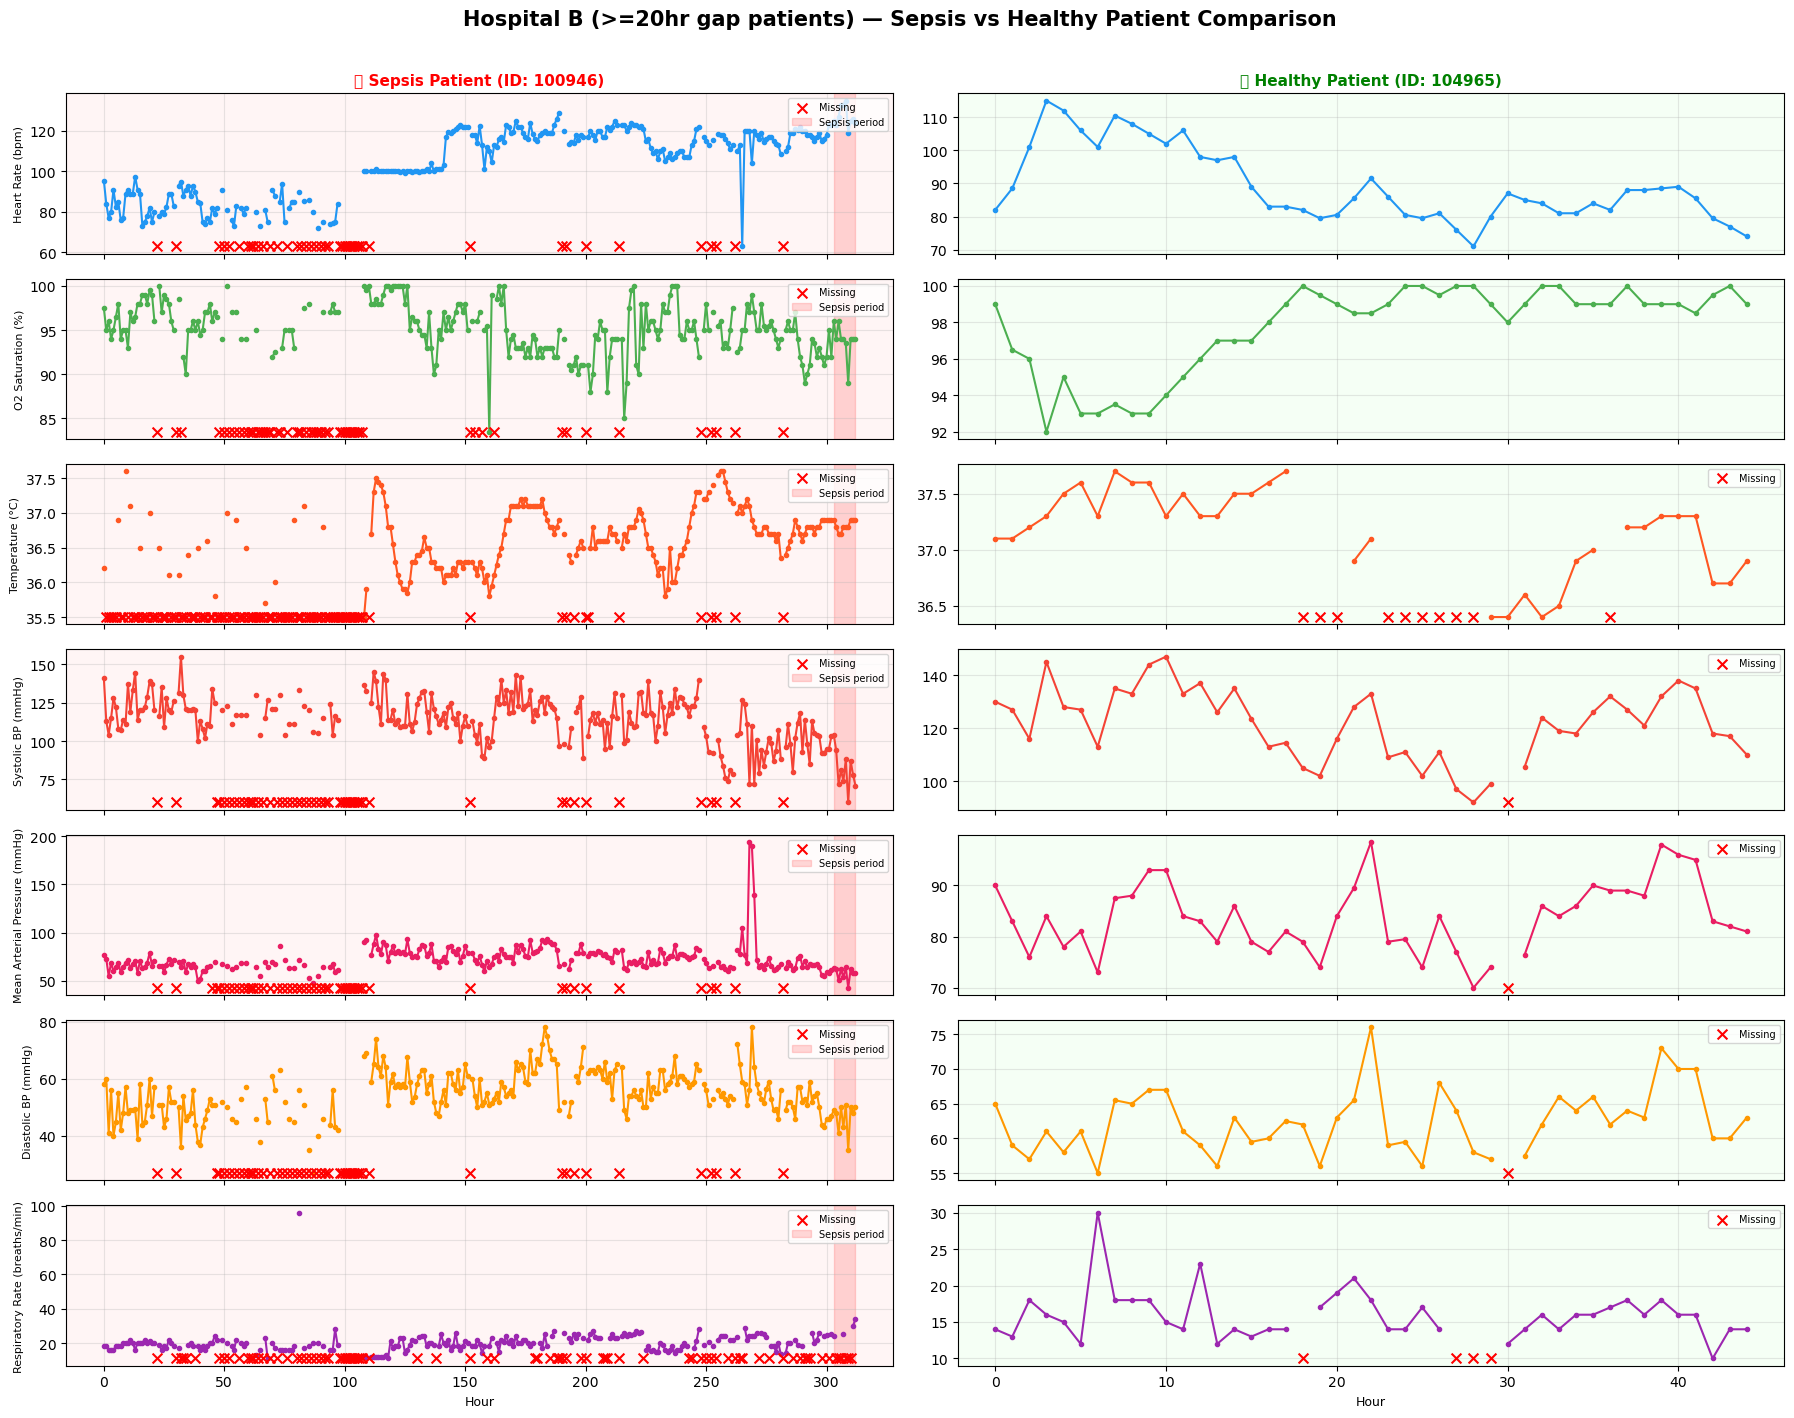

In [24]:
# -- Plot a random example from each ---------------------------------------------
plot_patient_timeseries(df_hospitalA_final, hospital_name=f"Hospital A (>={GAP_DROP_THRESHOLD}hr gap patients)")
plot_patient_timeseries(df_hospitalB_final, hospital_name=f"Hospital B (>={GAP_DROP_THRESHOLD}hr gap patients)")

In [25]:
def impute_patient(group, max_gap=6):
    """
    Hybrid imputation per patient:
    1. Linear interpolation for gaps <= max_gap hours
    2. Forward fill for remaining gaps
    3. Backward fill for leading NaNs
    """
    vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
    for col in vitals:
        group[col] = group[col].interpolate(method='linear', limit=max_gap)
        group[col] = group[col].ffill()
        group[col] = group[col].bfill()
    return group


def apply_imputation(df, hospital_name="Hospital", max_gap=6):
    """
    Applies hybrid imputation to the full dataset and reports results.
    """
    vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']

    print(f"\n{'='*55}")
    print(f"  {hospital_name} - Imputation Report")
    print(f"{'='*55}")
    print(f"\nBEFORE Imputation:")
    before     = df[vitals].isnull().sum()
    before_pct = (before / len(df) * 100).round(2)
    print(pd.DataFrame({'Missing Count': before, 'Missing %': before_pct}).to_string())

    df_imputed = df.groupby('Patient_ID', group_keys=False)[df.columns.tolist()].apply(
        lambda g: impute_patient(g, max_gap=max_gap)
    )

    print(f"\nAFTER Imputation (max_gap={max_gap} hours):")
    after     = df_imputed[vitals].isnull().sum()
    after_pct = (after / len(df_imputed) * 100).round(2)
    print(pd.DataFrame({'Missing Count': after, 'Missing %': after_pct}).to_string())

    still_missing = after[after > 0]
    if not still_missing.empty:
        print(f"\nRemaining missing values - patients with NO readings at all:")
        for col in still_missing.index:
            fully_missing = df_imputed.groupby('Patient_ID')[col].apply(
                lambda x: x.isnull().all()
            ).sum()
            print(f"   {col}: {fully_missing} patients have no readings at all")
    else:
        print(f"\nNo remaining missing values!")

    print(f"\n{'='*55}\n")
    return df_imputed


# -- Run on data after dropping >=20hr consecutive-gap patients ----------------
df_hospitalA_imputed = apply_imputation(df_hospitalA_final, hospital_name="Hospital A", max_gap=6)
df_hospitalB_imputed = apply_imputation(df_hospitalB_final, hospital_name="Hospital B", max_gap=6)


  Hospital A - Imputation Report

BEFORE Imputation:
       Missing Count  Missing %
HR             11834       3.16
O2Sat          19663       5.25
Temp          198985      53.16
SBP            12627       3.37
MAP            13045       3.48
DBP            14186       3.79
Resp           16184       4.32

AFTER Imputation (max_gap=6 hours):
       Missing Count  Missing %
HR                 0        0.0
O2Sat              0        0.0
Temp               0        0.0
SBP               14        0.0
MAP                0        0.0
DBP               14        0.0
Resp               8        0.0

Remaining missing values - patients with NO readings at all:
   SBP: 1 patients have no readings at all
   DBP: 1 patients have no readings at all
   Resp: 1 patients have no readings at all



  Hospital B - Imputation Report

BEFORE Imputation:
       Missing Count  Missing %
HR             51624       8.15
O2Sat          62888       9.93
Temp          389044      61.45
SBP            61315 

In [29]:
# -- Find bad patients per hospital separately -------------------------
bad_pid_A = df_hospitalA_imputed[df_hospitalA_imputed['MAP'].isnull()]['Patient_ID'].unique()
bad_pid_B = df_hospitalB_imputed[df_hospitalB_imputed['MAP'].isnull()]['Patient_ID'].unique()

print(f"Hospital A - patients with unresolved missing MAP: {bad_pid_A}")
print(f"Hospital B - patients with unresolved missing MAP: {bad_pid_B}")

# -- Drop separately ---------------------------------------------------
df_hospitalA_imputed_clean = df_hospitalA_imputed[
    ~df_hospitalA_imputed['Patient_ID'].isin(bad_pid_A)].copy()

df_hospitalB_imputed_clean = df_hospitalB_imputed[
    ~df_hospitalB_imputed['Patient_ID'].isin(bad_pid_B)].copy()

print(f"\nHospital A: {df_hospitalA_imputed['Patient_ID'].nunique()} → "
      f"{df_hospitalA_imputed_clean['Patient_ID'].nunique()} patients")
print(f"Hospital B: {df_hospitalB_imputed['Patient_ID'].nunique()} → "
      f"{df_hospitalB_imputed_clean['Patient_ID'].nunique()} patients")

Hospital A - patients with unresolved missing MAP: []
Hospital B - patients with unresolved missing MAP: [100402 109297 110229 113159]

Hospital A: 11551 → 11551 patients
Hospital B: 18722 → 18718 patients


Type       : Sepsis Patient
Patient ID : 1201
Hospital   : Hospital A (After simple imputation)
Hours      : 68
Sepsis     : Yes
--------------------------------------------------
No missing values for this patient

Type       : Healthy Patient
Patient ID : 7524
Hospital   : Hospital A (After simple imputation)
Hours      : 54
Sepsis     : No
--------------------------------------------------
No missing values for this patient



C:\Users\firas.hindawi.CCM\AppData\Local\Temp\ipykernel_31656\1855920012.py:98: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\firas.hindawi.CCM\AppData\Local\Temp\ipykernel_31656\1855920012.py:98: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\firas.hindawi.CCM\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\firas.hindawi.CCM\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


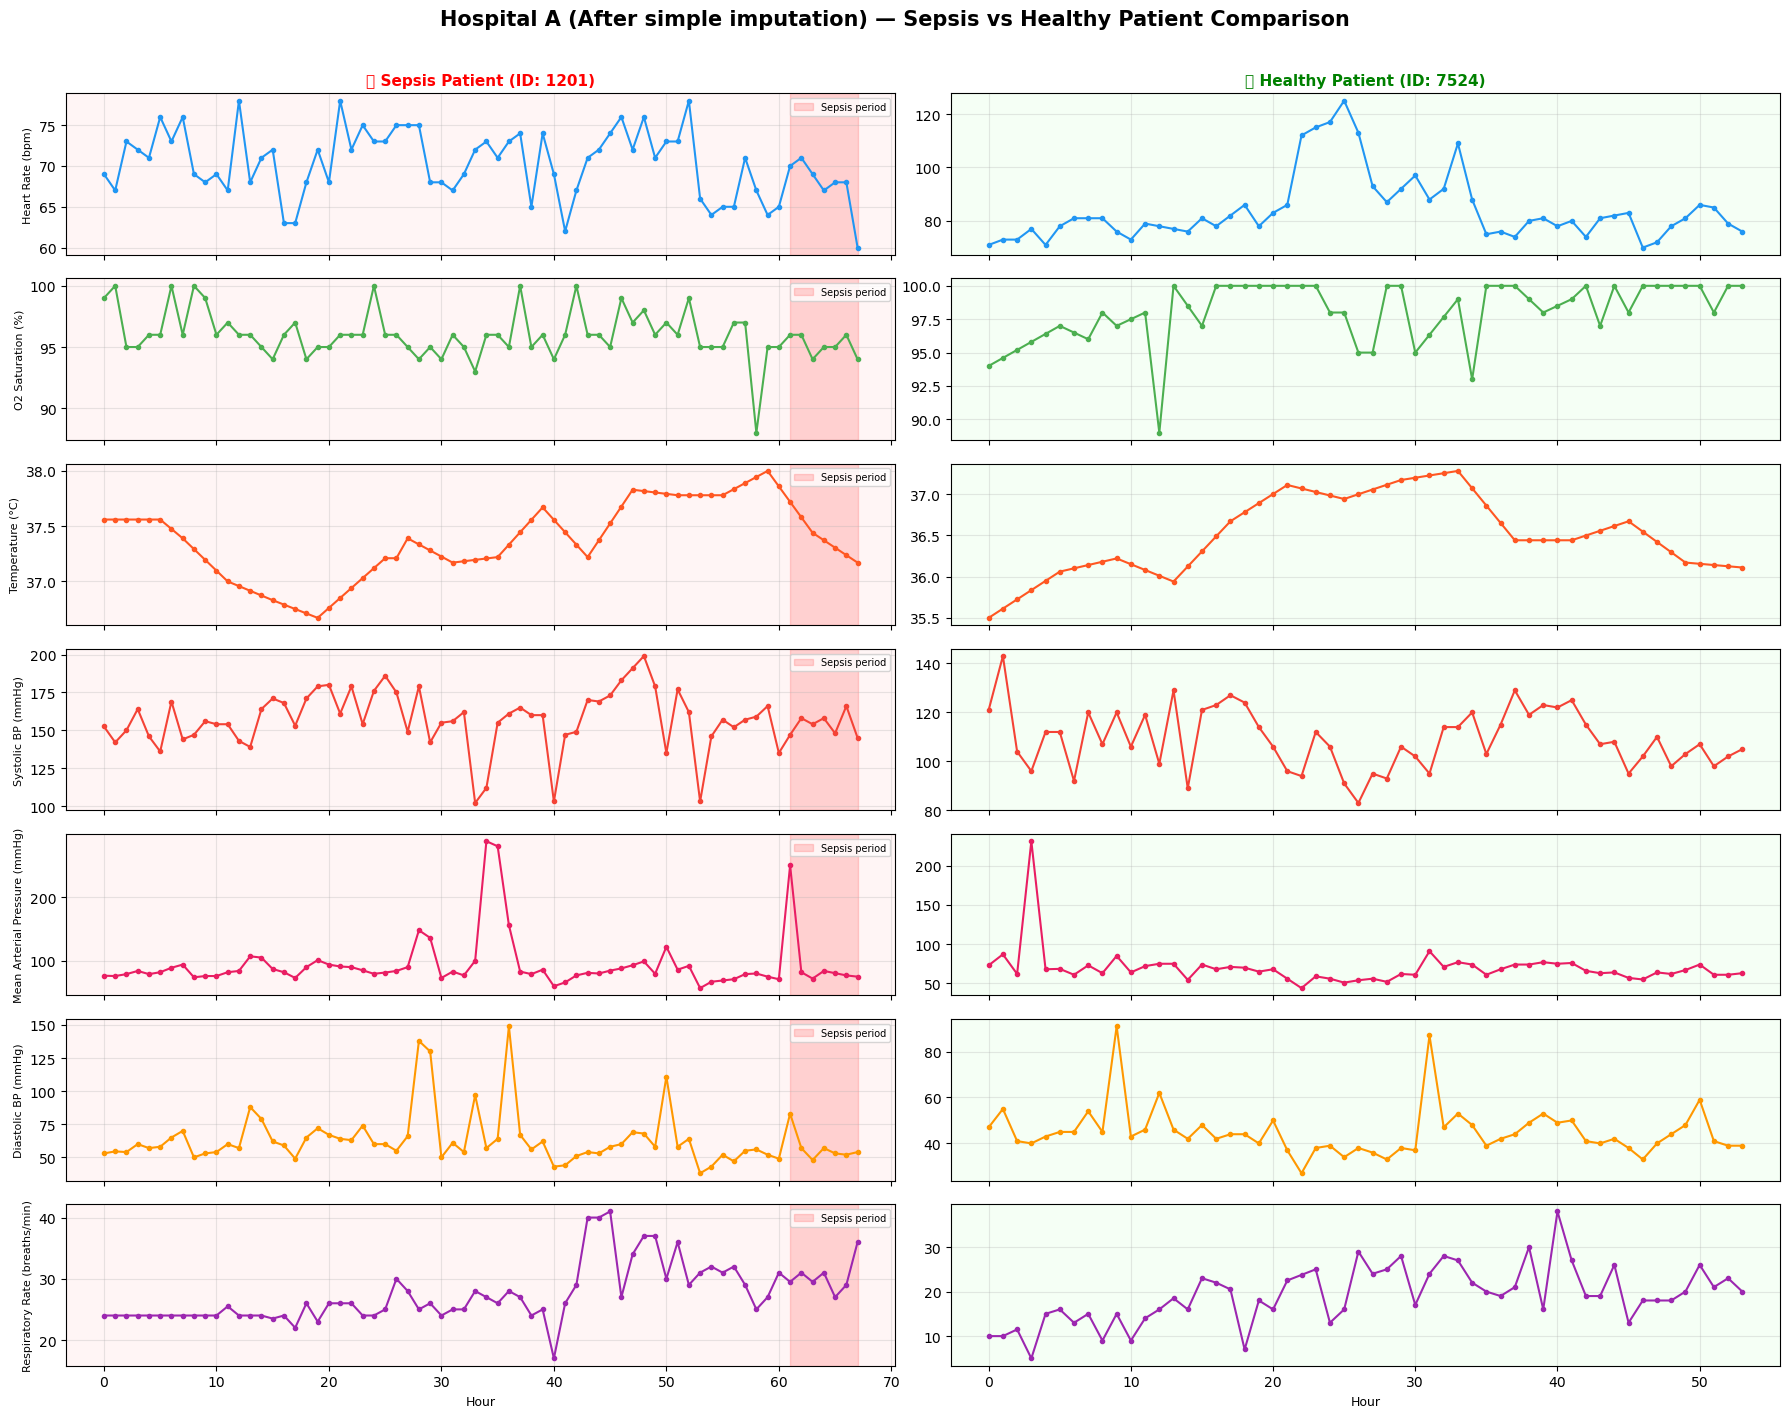

Type       : Sepsis Patient
Patient ID : 111540
Hospital   : Hospital B (After simple imputation)
Hours      : 31
Sepsis     : Yes
--------------------------------------------------
No missing values for this patient

Type       : Healthy Patient
Patient ID : 113644
Hospital   : Hospital B (After simple imputation)
Hours      : 38
Sepsis     : No
--------------------------------------------------
No missing values for this patient



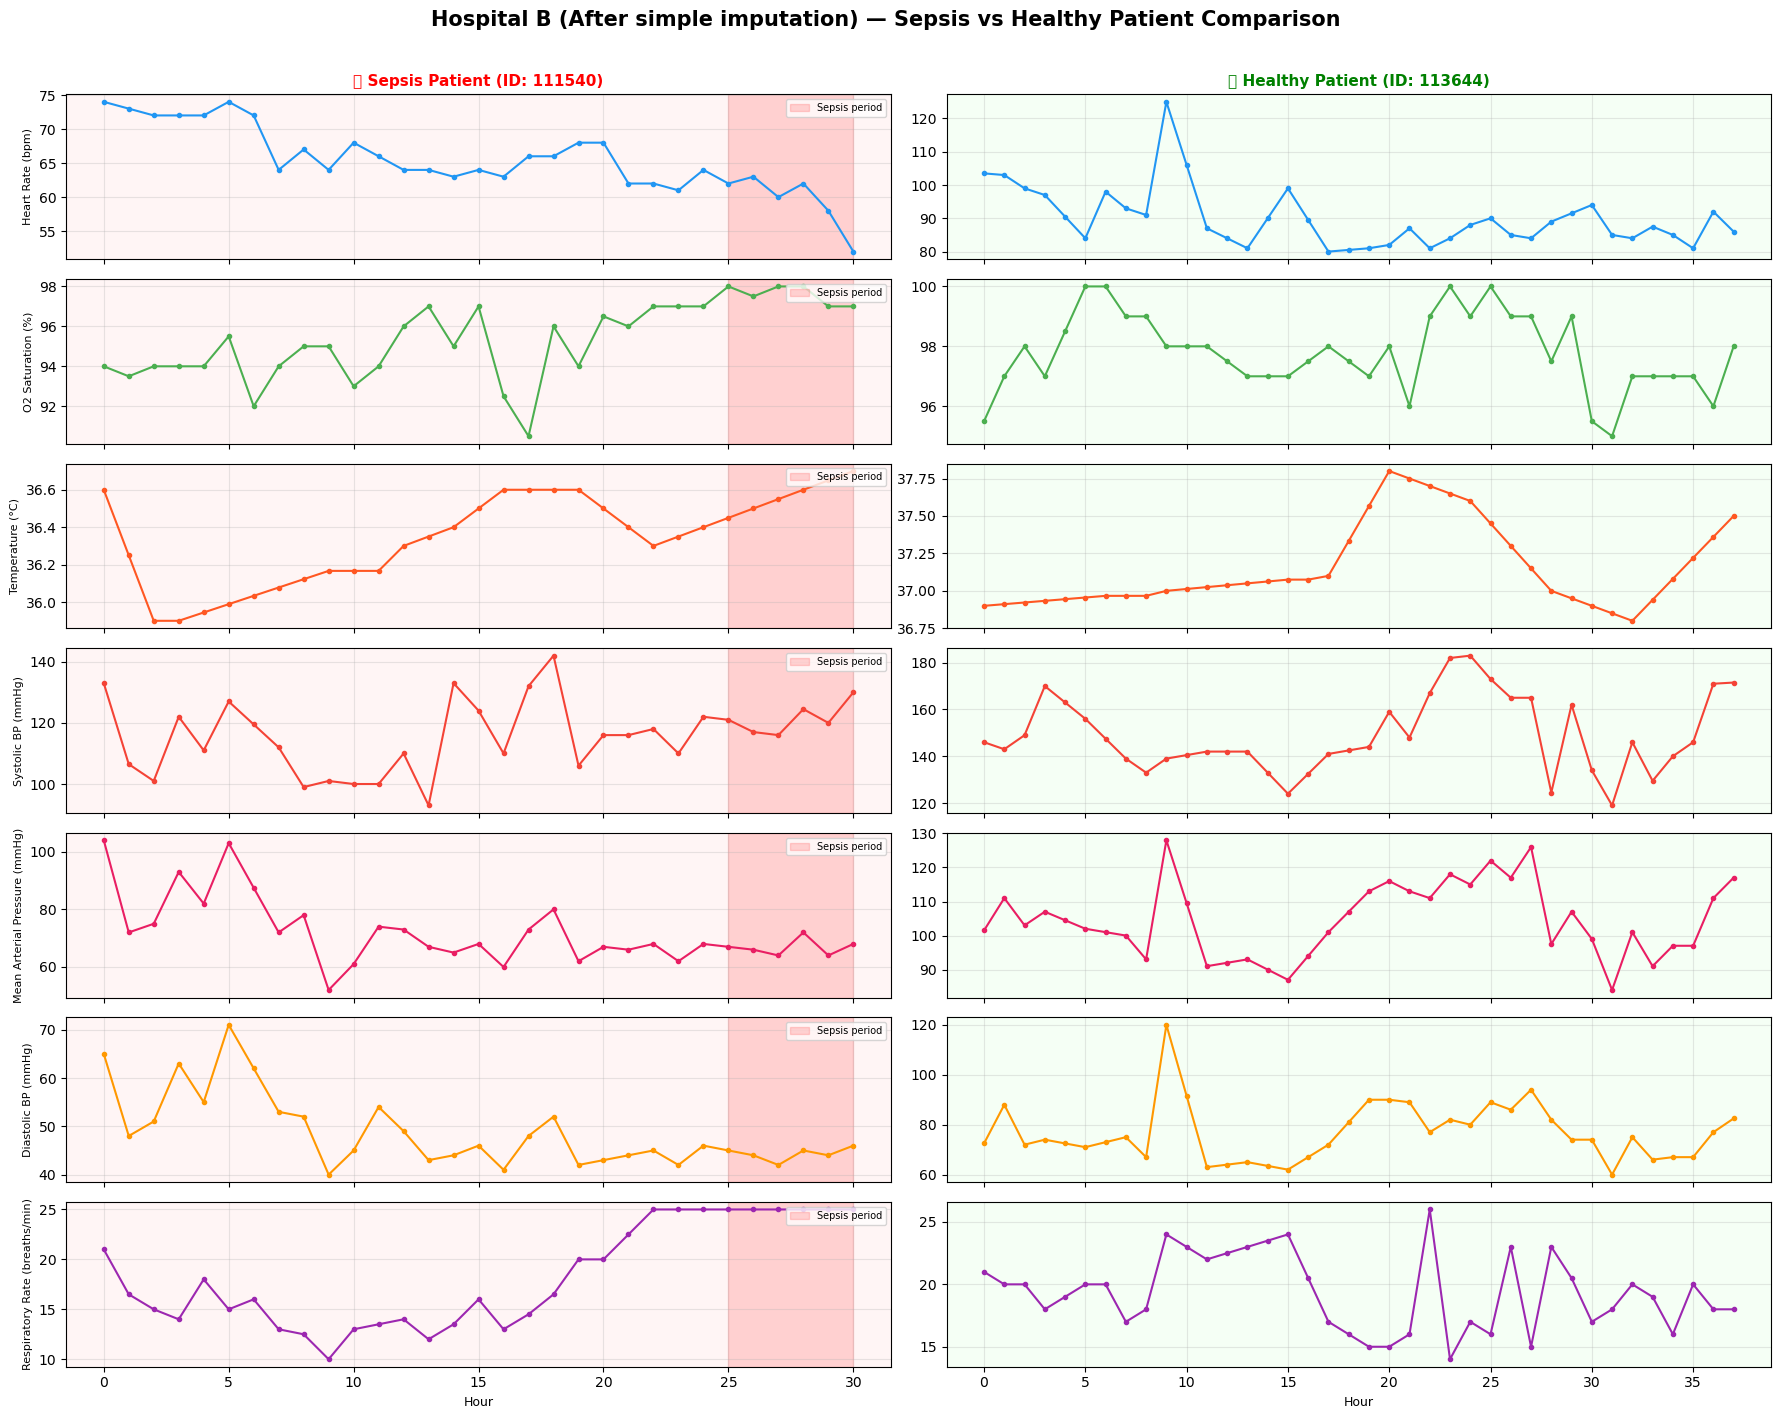

In [30]:
# -- Plot a random example from each ---------------------------------------------
plot_patient_timeseries(df_hospitalA_imputed_clean, hospital_name=f"Hospital A (After simple imputation)")
plot_patient_timeseries(df_hospitalB_imputed_clean, hospital_name=f"Hospital B (After simple imputation)")

In [31]:
def check_sepsis_label_changes(df_raw, df_final, hospital_name="Hospital"):
    """
    Checks how many patients changed sepsis status between raw and final data.
    
    Cases:
    1. Sepsis → Healthy : patient had SepsisLabel=1 in raw but all positive 
                          hours were trimmed away - now looks healthy (PROBLEM)
    2. Healthy → Sepsis : shouldn't happen (trimming can only remove rows)
    3. Retained correctly: sepsis status unchanged
    """
    
    # Per-patient max SepsisLabel in raw vs final
    raw_sepsis   = df_raw.groupby('Patient_ID')['SepsisLabel'].max().rename('raw')
    final_sepsis = df_final.groupby('Patient_ID')['SepsisLabel'].max().rename('final')
    
    # Only look at patients present in BOTH datasets
    combined = pd.concat([raw_sepsis, final_sepsis], axis=1).dropna()
    combined = combined.astype(int)
    
    # Classify each patient
    sepsis_to_healthy = combined[(combined['raw'] == 1) & (combined['final'] == 0)]
    healthy_to_sepsis = combined[(combined['raw'] == 0) & (combined['final'] == 1)]
    unchanged_sepsis  = combined[(combined['raw'] == 1) & (combined['final'] == 1)]
    unchanged_healthy = combined[(combined['raw'] == 0) & (combined['final'] == 0)]
    
    total = len(combined)
    
    print(f"\n{'='*65}")
    print(f"  {hospital_name} - Sepsis Label Integrity Check")
    print(f"{'='*65}")
    print(f"\n  Patients in both raw and final : {total:,}")
    print(f"\n  Unchanged sepsis  : {len(unchanged_sepsis):,} "
          f"({len(unchanged_sepsis)/total*100:.2f}%)")
    print(f"  Unchanged healthy : {len(unchanged_healthy):,} "
          f"({len(unchanged_healthy)/total*100:.2f}%)")
    print(f"\n  Sepsis → Healthy : {len(sepsis_to_healthy):,} "
          f"({len(sepsis_to_healthy)/total*100:.2f}%)  ← PROBLEM")
    print(f"  Healthy → Sepsis : {len(healthy_to_sepsis):,} "
          f"({len(healthy_to_sepsis)/total*100:.2f}%)  ← should be 0")
    
    if len(sepsis_to_healthy) > 0:
        print(f"\nPatients who lost their sepsis label (first 10):")
        print(f"  {list(sepsis_to_healthy.index[:10])}")
        
        # How many sepsis-positive hours did they have in raw?
        hours_check = []
        for pid in sepsis_to_healthy.index:
            raw_rows    = df_raw[df_raw['Patient_ID'] == pid]
            final_rows  = df_final[df_final['Patient_ID'] == pid]
            sepsis_hrs_raw   = (raw_rows['SepsisLabel'] == 1).sum()
            sepsis_hrs_final = (final_rows['SepsisLabel'] == 1).sum()
            total_hrs_raw    = len(raw_rows)
            total_hrs_final  = len(final_rows)
            hours_check.append({
                'Patient_ID':       pid,
                'Raw hrs':          total_hrs_raw,
                'Final hrs':        total_hrs_final,
                'Sepsis hrs (raw)': sepsis_hrs_raw,
                'Sepsis hrs (final)': sepsis_hrs_final,
            })
        
        df_hours = pd.DataFrame(hours_check)
        print(f"\n  Hours breakdown for affected patients:")
        print(df_hours.to_string(index=False))
        
        print(f"\nRecommendation:")
        print(f"   These {len(sepsis_to_healthy)} patients had their sepsis-positive")
        print(f"   hours trimmed away during preprocessing. They are now")
        print(f"   misclassified as healthy in the final dataset.")
        print(f"   → Remove them from the final dataset to prevent label leakage.")

    print(f"\n{'='*65}\n")
    
    return sepsis_to_healthy.index.tolist()



In [32]:
# -- Check for sepsis label changes caused by preprocessing ----------------
affected_A = check_sepsis_label_changes(
    df_raw=df_hospitalA,
    df_final=df_hospitalA_imputed_clean,
    hospital_name="Hospital A"
)

affected_B = check_sepsis_label_changes(
    df_raw=df_hospitalB,
    df_final=df_hospitalB_imputed_clean,
    hospital_name="Hospital B"
)

# -- Remove mislabelled patients -------------------------------------------
if affected_A:
    print(f"Removing {len(affected_A)} mislabelled patients from Hospital A...")
    df_hospitalA_imputed_clean = df_hospitalA_imputed_clean[
        ~df_hospitalA_imputed_clean['Patient_ID'].isin(affected_A)
    ].copy()

if affected_B:
    print(f"Removing {len(affected_B)} mislabelled patients from Hospital B...")
    df_hospitalB_imputed_clean = df_hospitalB_imputed_clean[
        ~df_hospitalB_imputed_clean['Patient_ID'].isin(affected_B)
    ].copy()

# -- Save checkpoints ------------------------------------------------------
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

df_hospitalA_imputed_clean['Hospital'] = 'A'
df_hospitalB_imputed_clean['Hospital'] = 'B'

df_hospitalA_imputed_clean.to_parquet(f"{checkpoint_dir}/hospitalA_imputed_clean.parquet", index=False)
df_hospitalB_imputed_clean.to_parquet(f"{checkpoint_dir}/hospitalB_imputed_clean.parquet", index=False)
df_hospitalA_imputed_clean.to_csv(f"{checkpoint_dir}/hospitalA_imputed_clean.csv", index=False)
df_hospitalB_imputed_clean.to_csv(f"{checkpoint_dir}/hospitalB_imputed_clean.csv", index=False)

print("Checkpoint saved:")
print(f"   Hospital A: {df_hospitalA_imputed_clean.shape[0]:,} rows, "
      f"{df_hospitalA_imputed_clean['Patient_ID'].nunique()} patients")
print(f"   Hospital B: {df_hospitalB_imputed_clean.shape[0]:,} rows, "
      f"{df_hospitalB_imputed_clean['Patient_ID'].nunique()} patients")


  Hospital A - Sepsis Label Integrity Check

  Patients in both raw and final : 11,551

  Unchanged sepsis  : 961 (8.32%)
  Unchanged healthy : 10,492 (90.83%)

  Sepsis → Healthy : 98 (0.85%)  ← PROBLEM
  Healthy → Sepsis : 0 (0.00%)  ← should be 0

Patients who lost their sepsis label (first 10):
  [203, 346, 379, 674, 1040, 1072, 1133, 1319, 1366, 1646]

  Hours breakdown for affected patients:
 Patient_ID  Raw hrs  Final hrs  Sepsis hrs (raw)  Sepsis hrs (final)
        203       81         55                10                   0
        346       64         14                 9                   0
        379       58         32                 9                   0
        674       83         33                10                   0
       1040      215        111                10                   0
       1072       61         51                 9                   0
       1133      101         51                 9                   0
       1319      184        141       

## Stats about the length of the timeseries

This is important to help us identify a reasonable window size that would not eliminate patients when windowing.

In [33]:
def stay_length_stats(df, hospital_name="Hospital"):
    """
    Computes patient stay-length statistics (in hours) to inform
    sliding-window size/step selection for seq2seq modeling.
    """
    stay_lengths = df.groupby('Patient_ID')['Hour'].count()

    stats = {
        'n_patients': len(stay_lengths),
        'min': stay_lengths.min(),
        'max': stay_lengths.max(),
        'mean': stay_lengths.mean(),
        'median': stay_lengths.median(),
        'mode': stay_lengths.mode().iloc[0],
        'std': stay_lengths.std(),
        'p10': stay_lengths.quantile(0.10),
        'p25': stay_lengths.quantile(0.25),
        'p75': stay_lengths.quantile(0.75),
        'p90': stay_lengths.quantile(0.90),
        'p95': stay_lengths.quantile(0.95),
    }

    print(f"\n{'='*55}")
    print(f"  {hospital_name} - Patient Stay Length Stats (hours)")
    print(f"{'='*55}")
    for k, v in stats.items():
        if k == 'n_patients':
            print(f"   {k:10s} : {v}")
        else:
            print(f"   {k:10s} : {v:.1f}")

    # -- How many patients fall below various candidate window sizes? ----
    print(f"\nPatients excluded entirely at various window sizes (stay < window):")
    for w in [6, 12, 18, 24, 30, 36, 48]:
        n_excluded = (stay_lengths < w).sum()
        pct = n_excluded / len(stay_lengths) * 100
        print(f"   window={w:>3}hrs : {n_excluded:>5} patients excluded ({pct:.1f}%)")

    print(f"{'='*55}\n")
    return stats, stay_lengths


stats_A, lengths_A = stay_length_stats(df_hospitalA_imputed_clean, hospital_name="Hospital A")
stats_B, lengths_B = stay_length_stats(df_hospitalB_imputed_clean, hospital_name="Hospital B")

# -- Combined (both hospitals together, since you'll train on combined data) --
combined_lengths = pd.concat([lengths_A, lengths_B])
print(f"\n{'='*55}")
print(f"  Combined (A+B) - Patient Stay Length Stats (hours)")
print(f"{'='*55}")
print(f"   n_patients : {len(combined_lengths)}")
print(f"   min        : {combined_lengths.min():.1f}")
print(f"   max        : {combined_lengths.max():.1f}")
print(f"   mean       : {combined_lengths.mean():.1f}")
print(f"   median     : {combined_lengths.median():.1f}")
print(f"   mode       : {combined_lengths.mode().iloc[0]:.1f}")
print(f"   std        : {combined_lengths.std():.1f}")
print(f"   p10        : {combined_lengths.quantile(0.10):.1f}")
print(f"   p25        : {combined_lengths.quantile(0.25):.1f}")
print(f"   p75        : {combined_lengths.quantile(0.75):.1f}")
print(f"   p90        : {combined_lengths.quantile(0.90):.1f}")
print(f"   p95        : {combined_lengths.quantile(0.95):.1f}")

print(f"\nPatients excluded entirely at various window sizes (combined):")
for w in [6, 12, 18, 24, 30, 36, 48]:
    n_excluded = (combined_lengths < w).sum()
    pct = n_excluded / len(combined_lengths) * 100
    print(f"   window={w:>3}hrs : {n_excluded:>5} patients excluded ({pct:.1f}%)")
print(f"{'='*55}\n")


  Hospital A - Patient Stay Length Stats (hours)
   n_patients : 11453
   min        : 6.0
   max        : 333.0
   mean       : 32.2
   median     : 30.0
   mode       : 21.0
   std        : 21.6
   p10        : 13.0
   p25        : 19.0
   p75        : 41.0
   p90        : 49.0
   p95        : 54.0

Patients excluded entirely at various window sizes (stay < window):
   window=  6hrs :     0 patients excluded (0.0%)
   window= 12hrs :   755 patients excluded (6.6%)
   window= 18hrs :  2369 patients excluded (20.7%)
   window= 24hrs :  4477 patients excluded (39.1%)
   window= 30hrs :  5597 patients excluded (48.9%)
   window= 36hrs :  7039 patients excluded (61.5%)
   window= 48hrs : 10063 patients excluded (87.9%)


  Hospital B - Patient Stay Length Stats (hours)
   n_patients : 18680
   min        : 6.0
   max        : 334.0
   mean       : 33.8
   median     : 33.0
   mode       : 37.0
   std        : 22.6
   p10        : 13.0
   p25        : 20.0
   p75        : 42.0
   p90     